# Bit-argument debate — last-$d_B$ rule, FashionMNIST (per-class whitened)

Tests the "minimal arguments" experiment: along with **each revealed cell**, the
agent also emits a symbol from a small alphabet (default $\{0,1\}$, one bit per
cell). The symbols carry no prior meaning — whatever semantics they end up
having is learned in equilibrium. If the symbol version wins, the judge is
learning to offload computation onto the agents, who can encode the result of
their (exhaustive) search into the extra bits.

**Channel capacity is fixed at $K = 4$ bits per play** — one per revealed cell —
for every protocol, so 2-turn, 4-turn and consultancy are compared at equal
channel width. What differs is *who* chooses which bits and *when*:

| protocol | decisions | alphabet per decision | total |
|---|---|---|---|
| 4-turn debate | $A,B,A,B$ — 1 bit each | $V=2$ | 4 bits |
| 2-turn debate | $A$ picks bits 1–2, $B$ picks 3–4 | $V=4$ | 4 bits |
| consultancy | $A$ picks all 4 at once | $V=16$ | 4 bits |

The judge always sees the same object: 4 binary features in reveal order, so
in the debate arms it can tell $A$'s bits from $B$'s by position. Enumerating
the channel therefore costs $2^4=16\times$ the judge evaluations in every bit
arm, which is what sets the mask-search budget below.

**Protocol (fixed): last-$d_B$, claim-conditioned judge (D3).**

1. $A$ commits a class $d_A$.
2. Cells are revealed, alternating: 2-turn ($A$ picks 2 cells, $B$ picks 2) or
   4-turn ($A,B,A,B$, one cell each). **Each turn also emits one symbol.**
3. After the full reveal, $B$ commits $d_B$.
4. Judge sees: $A$'s reveal channel, $B$'s reveal channel, $\text{onehot}(d_A)$,
   $\text{onehot}(d_B)$, and the **symbol sequence in turn order** (so the judge
   knows who said what and when). It outputs 10 logits, trained with CE on $y$.

The value $A$ maximizes / $B$ minimizes is $p[\text{play}, d_A]$ with $B$'s last
move being $d_B = \arg\min_{d} p[\text{play}, d_A \mid d_B{=}d]$ — bit-identical
to the `lastdig` reduce of `claim_conditioned_judges_sweep.ipynb`. A *move* is
now the pair (cell, symbol), so the branching factor per turn is
(cell candidates) $\times V$.

**The control.** Every bit arm has one control: the *same* protocol with the
*same* mask search, minus the channel.

| arm | channel | mask search | judge evals / image |
|---|---|---|---|
| `2turn_bits` / `4turn_bits` | 4 bits | 256 cell paths | 4096 |
| `2turn_control` / `4turn_control` | — | 256 cell paths | 256 |
| `consultancy_bits_324` | 4 bits | 324 masks | 5184 |
| `consultancy_324` | — | 324 masks | 324 |
| `consultancy_1296` | — | 1296 masks | 1296 |

The control is **exactly nested** inside the treatment: if the judge's output
does not depend on the symbol inputs, then $L$ is constant in the symbol, so
$\min$ / $\max$ over (cell, symbol) equals $\min$ / $\max$ over cell, and the
two arms produce the same claim, the same $d_B$ and the same reveal on the
same sampled masks. A null result is therefore a real null — no "did the
search change?" confound to unpick. `check_control_nesting()` below verifies
this on the actual implementation.

The bit arm needs $V^T$ times as many judge evaluations as its control,
because searching the symbol dimension is what the treatment *is*; that cost
is the treatment's own price, not an advantage to be neutralised by handing
the control extra masks. (Spending the same evaluations on $V^T\times$ more
masks instead is a *resource-allocation* question — "is a channel a better
buy than more search?" — and a different experiment, not a control. Add it as
a third arm with `(2, 'more_masks'): (36, 36)` if you want that comparison.)

**Baselines**, both on this same architecture, since the base sweep's numbers
were measured on the shallow head and don't transfer:

* **consultancy** — $A$ commits a class and shows the single mask that best
  supports it; judge sees the mask and $d_A$, no adversary. Run plain at 1296
  masks (the base sweep's budget, so its 75.46 row is the thing to compare
  against) and at 324 masks, and **with the 4-bit channel** at 324 masks --
  `consultancy_324` is the nested control for `consultancy_bits_324`, exactly
  as `Nturn_control` is for `Nturn_bits`. So the channel is tested twice, once
  inside debate and once inside consultancy.
  Note consultancy searches more masks than the debate arms here (324/1296 vs
  256), which if anything favours consultancy.
* **random mask** — no agent at all: a judge trained on uniform 4/36 masks,
  reported both on a single random mask (the 55.61 "sparse judge" row) and as
  the ensemble over 256 random masks, which is the zero-capability floor every
  protocol collapses to and the number nothing in the quantilizer sweep beat.

**Deeper head.** The MLP head is deepened (3 hidden layers by default, vs. 1 in
the base notebook) so it can actually compute something with the symbols rather
than just linearly reading them off. All arms share the same architecture — the
no-symbol arms differ only in the missing symbol input dims.

Everything else (CNN backbone, geometry, optimizer, epochs, dataset pipeline)
is unchanged from `claim_conditioned_judges_sweep.ipynb`.

**Caveat on comparability.** Enumerating a 4-bit channel costs $16\times$ the
judge evaluations, so the debate arms search 256 masks where the base sweep
searched 1296. Together with the deeper head, absolute numbers are *not*
directly comparable to the last-$d_B$ rows of the claim-conditioned sweep
(FMNIST-wh. 75.38 / 66.79 for debate 2- / 4-turn). Every comparison that
matters here is against `control` at the same mask search.

In [1]:
import os, gc, time, copy, math, itertools
from functools import partial
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.optim.lr_scheduler import ExponentialLR
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

torch.backends.cudnn.benchmark = True

CONFIG = {
    # ----- dataset -----
    'dataset':            'fashionmnist_normalized',
    # ----- image / mask geometry (unchanged) -----
    'img_size':           18,
    'grid_size':          6,
    'squares_to_keep':    4,
    # ----- training (unchanged from the base notebook) -----
    'batch_size':         128,
    'epochs':             15,
    'lr':                 1e-3,
    'lr_decay':           0.85,
    # ----- argument channel -----
    # bits per REVEALED CELL, so a play carries squares_to_keep * bits_per_cell
    # bits in every protocol. 1 -> 4 bits/play -> 2^4 = 16 symbol sequences to
    # enumerate. 2 would mean 8 bits -> 256 sequences: 16x the cost, don't.
    'bits_per_cell':      1,
    # ----- judge architecture -----
    'proj_dim':           64,         # CNN feats -> proj_dim, once per cell path
    'mlp_hidden':         64,         # base notebook: 64, single layer
    'mlp_hidden_layers':  3,          # was 1  <-- the "deeper head"
    'mlp_dropout':        0.1,
    # ----- search -----
    # The matched quantity is the MASK search (cell paths per image), set in
    # BRANCHING. The bit arm costs V^T times as many judge evaluations on top.
    'turn_counts':        (2, 4),
    'arms':               ('bits', 'control'),
    # ----- baselines (same architecture, same training steps) -----
    # consultancy: A picks (mask, class) maximizing P(d_A | mask, d_A).
    #   1296 = the base sweep's consultancy budget (anchors to its 75.46 row);
    #    324 = the 2-turn arms' mask search (search-matched comparison).
    'consultancy_masks':      (1296, 324),   # plain
    'consultancy_bits_masks': (324,),        # with the 4-bit channel;
                                             # its control is consultancy_324
    # random-mask judge: no agent at all. P(y | uniform 4/36 mask), plus the
    # ensemble (average over `ensemble_masks` random masks), which is the
    # zero-capability floor every protocol collapses to.
    'run_random_baseline': True,
    'run_gold':            True,     # full-image classifier: the accuracy ceiling
    'plain_epochs':        15,       # for the gold / random-mask judges
    # The EXACT ensemble: average the judge over all C(36,4) = 58905 masks of
    # each test image. This is the zero-capability limit of the whole protocol
    # family (the q -> N quantilizer), so it is the number to beat. One-off cost
    # ~15-25 min on a T4; set False to skip.
    'full_ensemble':       True,
    'ensemble_img_batch':  16,
    'ensemble_mask_chunk': 4096,
    # ----- forward chunk sizes -----
    'cnn_chunk':          8192,       # cell paths pushed through the CNN at once
    'head_rows_chunk':    262144,     # rows through the MLP head at once
    'eval_amp':           True,
    'eval_batch':         64,
    # ----- multi-GPU (Kaggle 2xT4): splits the selection forward across GPUs -----
    'multi_gpu':          True,
    # ----- IO -----
    'data_root':          './data',
    'out_root':           '/kaggle/working' if os.path.isdir('/kaggle/working') else '.',
    'device':             'cuda' if torch.cuda.is_available() else 'cpu',
    'seed_base':          0,
}
CONFIG['plot_dir']    = os.path.join(CONFIG['out_root'], 'bitarg_plots')
CONFIG['data_dir']    = os.path.join(CONFIG['out_root'], 'bitarg_data')
CONFIG['weights_dir'] = os.path.join(CONFIG['out_root'], 'bitarg_weights')
NUM_CLASSES = 10

# Mask-search branching per (n_turns, arm). A turn's branching is
# (cell candidates) x (its alphabet), so `bits` and `control` MUST share the same
# cell-candidate counts -- that is what makes the control nested.
#   2-turn: 16*16   = 256 cell paths -> bits 256 * 16 = 4096 judge evals
#   4-turn: 4*4*4*4 = 256 cell paths -> bits 256 * 16 = 4096 judge evals
# The two turn counts are matched on mask search as well as on channel width,
# and every turn has the same branching. (The base sweep used 1296 cell paths
# and no channel.) The mask choice is itself a log2(256) = 8-bit channel, so the
# 4 extra bits widen the agents' message space by half again.
#
# Cheaper (~1.8x faster overall) if the runtime estimate below is too large:
#   (2, *): (12, 12)      -> 144 cell paths
#   (4, *): (4, 4, 3, 3)  -> 144 cell paths
BRANCHING = {
    (2, 'bits'):    (16, 16),
    (2, 'control'): (16, 16),
    (4, 'bits'):    (4, 4, 4, 4),
    (4, 'control'): (4, 4, 4, 4),
}

for d in (CONFIG['plot_dir'], CONFIG['data_dir'], CONFIG['weights_dir']):
    os.makedirs(d, exist_ok=True)

# Resolve the device list for the selection forward.
if CONFIG['device'] == 'cuda':
    _n_gpu = torch.cuda.device_count()
    CONFIG['devices'] = ([f'cuda:{i}' for i in range(_n_gpu)]
                         if (CONFIG['multi_gpu'] and _n_gpu > 1) else ['cuda:0'])
    CONFIG['device'] = 'cuda:0'
else:
    CONFIG['devices'] = ['cpu']
    CONFIG['multi_gpu'] = False

print(f"device: {CONFIG['device']} | selection devices: {CONFIG['devices']}")
if CONFIG['device'].startswith('cuda'):
    for i in range(torch.cuda.device_count()):
        print(f"  GPU{i}: {torch.cuda.get_device_name(i)} | "
              f"free {torch.cuda.mem_get_info(i)[0]/1e9:.2f} GB")
N_BITS = CONFIG['squares_to_keep'] * CONFIG['bits_per_cell']
print(f"dataset: {CONFIG['dataset']} | channel: {N_BITS} bits/play "
      f"({2**N_BITS} symbol sequences to enumerate)")
print(f"head: {CONFIG['mlp_hidden_layers']} x {CONFIG['mlp_hidden']} hidden "
      f"(base notebook: 1 x 64)")

device: cuda:0 | selection devices: ['cuda:0', 'cuda:1']
  GPU0: Tesla T4 | free 15.53 GB
  GPU1: Tesla T4 | free 15.53 GB
dataset: fashionmnist_normalized | channel: 4 bits/play (16 symbol sequences to enumerate)
head: 3 x 64 hidden (base notebook: 1 x 64)


In [2]:
# Self-contained dataset loader (identical to claim_conditioned_judges_sweep.ipynb).

DATASET_REGISTRY = {
    'mnist':        (torchvision.datasets.MNIST,        1),
    'fashionmnist': (torchvision.datasets.FashionMNIST, 1),
    'cifar10':      (torchvision.datasets.CIFAR10,      3),
}


def _parse_tag(tag):
    if tag.endswith('_normalized'):
        return tag[:-len('_normalized')], True
    return tag, False


def _materialize(ds, img_size, channels):
    n = len(ds)
    X = torch.empty(n, channels, img_size, img_size, dtype=torch.float32)
    y = torch.empty(n, dtype=torch.long)
    resize = transforms.Resize((img_size, img_size), antialias=True)
    to_tensor = transforms.ToTensor()
    for i in range(n):
        img, lbl = ds[i]
        X[i] = to_tensor(resize(img))
        y[i] = lbl
    return X, y


def preprocess_dataset(tag, config=CONFIG):
    base, normalized = _parse_tag(tag)
    cls, channels = DATASET_REGISTRY[base]
    img_size = config['img_size']
    print(f"  loading {base} (normalize_per_class={normalized})...")
    train_raw = cls(root=config['data_root'], train=True,  download=True)
    test_raw  = cls(root=config['data_root'], train=False, download=True)
    Xtr, ytr = _materialize(train_raw, img_size, channels)
    Xte, yte = _materialize(test_raw,  img_size, channels)

    mean = Xtr.mean(dim=(0, 2, 3), keepdim=True)
    std  = Xtr.std(dim=(0, 2, 3),  keepdim=True).clamp_min(1e-6)
    Xtr = (Xtr - mean) / std
    Xte = (Xte - mean) / std

    if normalized:
        lam_shrink = 0.05
        D = channels * img_size * img_size
        X_all = torch.cat([Xtr, Xte], dim=0).view(-1, D).double()
        y_all = torch.cat([ytr, yte], dim=0)
        global_mean = X_all.mean(dim=0, keepdim=True)
        eye_D = torch.eye(D, dtype=X_all.dtype)
        mus, Ws = [], []
        for k in range(10):
            Xk = X_all[y_all == k]
            mu_k = Xk.mean(dim=0, keepdim=True)
            Xc = Xk - mu_k
            Sigma_k = (Xc.T @ Xc) / (Xc.size(0) - 1)
            trace_per_d = Sigma_k.diagonal().mean()
            Sigma_reg = Sigma_k + lam_shrink * trace_per_d * eye_D
            eigvals, U = torch.linalg.eigh(Sigma_reg)
            eigvals = eigvals.clamp_min(eigvals.max() * 1e-8)
            W_k = (U * eigvals.rsqrt().unsqueeze(0)) @ U.T
            mus.append(mu_k); Ws.append(W_k)
        def _apply(X, y):
            Xflat = X.view(X.size(0), D).double()
            out = torch.empty_like(Xflat)
            for k in range(10):
                m = (y == k)
                if m.any():
                    out[m] = (Xflat[m] - mus[k]) @ Ws[k] + global_mean
            return out.float().view(X.size(0), channels, img_size, img_size)
        Xtr = _apply(Xtr, ytr); Xte = _apply(Xte, yte)

    dev = config['device']
    return {
        'name':        tag,
        'normalized':  normalized,
        'X_train':     Xtr.to(dev),
        'y_train':     ytr.to(dev),
        'X_test':      Xte.to(dev),
        'y_test':      yte.to(dev),
        'in_channels': channels,
        'img_size':    img_size,
    }


print("Loading data ...")
DATA = preprocess_dataset(CONFIG['dataset'])
print(f"  X_train: {tuple(DATA['X_train'].shape)} | X_test: {tuple(DATA['X_test'].shape)}")

Loading data ...
  loading fashionmnist (normalize_per_class=True)...


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 308kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.8MB/s]


  X_train: (60000, 1, 18, 18) | X_test: (10000, 1, 18, 18)


In [3]:
# The argument channel.
#
# A play reveals K cells and carries N_BITS = K * bits_per_cell bits. The bits
# are grouped into DECISIONS by the protocol: a decision is one agent choosing,
# at one turn, the bits for the cells it reveals at that turn. So the per-turn
# alphabet is V_t = 2^(bits revealed at turn t):
#
#   4-turn debate: 4 decisions of V=2   (A, B, A, B)
#   2-turn debate: 2 decisions of V=4   (A takes bits 1-2, B takes bits 3-4)
#   consultancy:   1 decision  of V=16  (A takes all four)
#
# For the minmax every symbol sequence must be enumerated, because the symbol is
# part of the move. A sequence is identified by a combo index g in [0, 2^N_BITS);
# g unflattens into per-decision symbols with decision 1 MOST significant (the
# order a tensor of shape (V_1, ..., V_T) unflattens into), and simultaneously
# the binary expansion of g, MSB first, IS the bit vector the judge reads. Those
# two facts agree because each decision owns a contiguous, correctly ordered
# block of bits -- which is what makes one table serve every protocol.


def make_arg_table(n_bits, device='cpu'):
    """(2^n_bits, n_bits) float: row g = binary expansion of g, MSB first."""
    g = torch.arange(2 ** n_bits)
    shifts = torch.arange(n_bits - 1, -1, -1)
    return ((g.unsqueeze(1) >> shifts.unsqueeze(0)) & 1).float().to(device)


def combo_index(symbols, Vs):
    """Per-decision symbol indices -> flat combo index (decision 1 major)."""
    g = torch.zeros_like(symbols[0])
    for s, V in zip(symbols, Vs):
        g = g * V + s
    return g


def bit_owners(n_turns, bits_per_decision):
    """Which agent emitted each bit, in reveal order. Consultancy is all A."""
    if n_turns == 0:
        return ['A'] * bits_per_decision
    return [('A' if t % 2 == 0 else 'B')
            for t in range(n_turns) for _ in range(bits_per_decision)]


# sanity
_f = make_arg_table(4)
assert _f.shape == (16, 4)
assert _f[5].tolist() == [0., 1., 0., 1.]                      # 5 = 0b0101
# 2-turn: g = s_A * 4 + s_B, so A owns the two leading bits
_g = combo_index([torch.tensor([2]), torch.tensor([1])], (4, 4))
assert int(_g) == 9 and _f[9].tolist() == [1., 0., 0., 1.]     # A=0b10, B=0b01
# 4-turn: g = b1*8 + b2*4 + b3*2 + b4
_g = combo_index([torch.tensor([1]), torch.tensor([0]),
                  torch.tensor([1]), torch.tensor([1])], (2, 2, 2, 2))
assert int(_g) == 11 and _f[11].tolist() == [1., 0., 1., 1.]
assert bit_owners(2, 2) == ['A', 'A', 'B', 'B']
assert bit_owners(4, 1) == ['A', 'B', 'A', 'B']
assert bit_owners(0, 4) == ['A'] * 4
print("arg table OK")

arg table OK


In [4]:
# JudgeClassifier: CNN backbone (identical to the base notebook) + a DEEPER MLP
# head that takes (projected features, onehot d_A, onehot d_B, symbol one-hots).
#
# n_arg_dims = 0 gives the no-symbol control judges: same everything, minus the
# symbol input dims.


class JudgeClassifier(nn.Module):
    def __init__(self, in_channels, img_size=18, num_classes=10, widen=1,
                 n_query_digits=2, n_arg_dims=0, proj_dim=64,
                 mlp_hidden=96, mlp_hidden_layers=3, dropout=0.1):
        super().__init__()
        c1, c2 = 32 * widen, 32 * widen
        self.features_net = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        feat_hw = img_size // 4
        cnn_feat_dim = c2 * feat_hw * feat_hw
        # Learned projection, run ONCE per cell path, so the per-(d_A, d_B,
        # symbols) head cost stays small.
        self.projection = nn.Sequential(
            nn.Linear(cnn_feat_dim, proj_dim),
            nn.ReLU(inplace=True),
        )
        self.feat_dim = proj_dim
        self.num_classes = num_classes
        self.n_query_digits = n_query_digits
        self.n_arg_dims = n_arg_dims

        head_in = proj_dim + n_query_digits * num_classes + n_arg_dims
        self.head_in = head_in
        layers, d = [], head_in
        for _ in range(mlp_hidden_layers):
            layers += [nn.Linear(d, mlp_hidden), nn.ReLU(inplace=True),
                       nn.Dropout(dropout)]
            d = mlp_hidden
        layers += [nn.Linear(d, num_classes)]
        self.head = nn.Sequential(*layers)

    def features_for(self, x):
        return self.projection(self.features_net(x).flatten(1))     # (B, proj_dim)

    def head_logits(self, feat, d_A=None, d_B=None, args=None):
        parts = [feat]
        if self.n_query_digits >= 1:
            assert d_A is not None, "judge expects d_A"
            parts.append(F.one_hot(d_A, self.num_classes).float())
        if self.n_query_digits >= 2:
            assert d_B is not None, "judge expects d_B"
            parts.append(F.one_hot(d_B, self.num_classes).float())
        if self.n_arg_dims:
            assert args is not None, "judge expects an argument vector"
            parts.append(args)
        else:
            assert args is None, "no-argument judge got an argument vector"
        return self.head(torch.cat(parts, dim=-1))

    def forward(self, x, d_A=None, d_B=None, args=None):
        return self.head_logits(self.features_for(x), d_A, d_B, args)


def _widen_for(data):
    return 2 if data['in_channels'] == 3 else 1


def make_judge(data, in_ch_mult, n_query_digits, n_arg_dims=0, config=CONFIG):
    """in_ch_mult: 1 for a single reveal channel (consultancy / random-mask
    baseline), 2 for the debate judges (A's channel + B's)."""
    return JudgeClassifier(
        in_channels=in_ch_mult * data['in_channels'], img_size=data['img_size'],
        widen=_widen_for(data), num_classes=NUM_CLASSES,
        n_query_digits=n_query_digits,
        n_arg_dims=n_arg_dims, proj_dim=config['proj_dim'],
        mlp_hidden=config['mlp_hidden'],
        mlp_hidden_layers=config['mlp_hidden_layers'],
        dropout=config['mlp_dropout']).to(config['device'])


def make_judge_for_arm(arm, data, config=CONFIG):
    return make_judge(data, arm['in_ch_mult'], arm['n_query_digits'],
                      arm['n_arg_dims'], config)


def make_debate_judge(data, n_arg_dims, config=CONFIG):     # kept for the checks
    return make_judge(data, 2, 2, n_arg_dims, config)

In [5]:
# Sampling helpers (identical to the base notebook -- cells only; symbols are
# enumerated exhaustively rather than sampled).


def _amp_ctx(device, use_amp):
    if use_amp and str(device).startswith('cuda'):
        return torch.amp.autocast(device_type='cuda', dtype=torch.float16)
    return nullcontext()


def cells_to_pixel_mask(cells, grid_size, img_size):
    G = grid_size
    step = img_size // G
    shape = cells.shape[:-1]
    out = cells.reshape(*shape, 1, G, G)
    out = out.repeat_interleave(step, dim=-2).repeat_interleave(step, dim=-1)
    return out


def sample_consultancy_masks(B, M, grid_size, squares_to_keep, device):
    K = grid_size * grid_size
    rand = torch.rand(B, M, K, device=device)
    idx = rand.argsort(dim=2)[:, :, :squares_to_keep]
    out = torch.zeros(B, M, K, device=device)
    out.scatter_(2, idx, 1.0)
    return out


def sample_2turn_paths(B, N_A, N_B, grid_size, device):
    K = grid_size * grid_size
    rand_A = torch.rand(B, N_A, K, device=device)
    a_idx = rand_A.argsort(dim=2)[:, :, :2]
    a_cells = torch.zeros(B, N_A, K, device=device)
    a_cells.scatter_(2, a_idx, 1.0)

    avail = 1.0 - a_cells
    rand_B = torch.rand(B, N_A, N_B, K, device=device)
    rand_B = torch.where(avail.unsqueeze(2).bool(),
                         rand_B, torch.full_like(rand_B, -1.0))
    b_idx = rand_B.topk(2, dim=3, largest=True).indices
    b_cells = torch.zeros(B, N_A, N_B, K, device=device)
    b_cells.scatter_(3, b_idx, 1.0)
    return a_cells, b_cells, a_idx, b_idx


def sample_4turn_paths(B, N_a1, N_b1, N_a2, N_b2, grid_size, device):
    K = grid_size * grid_size

    def _pick_one(avail, rand):
        rand = torch.where(avail.bool(), rand, torch.full_like(rand, -1.0))
        return rand.argmax(dim=-1)

    ones_full = torch.ones(B, N_a1, K, device=device)
    a1_idx = _pick_one(ones_full, torch.rand(B, N_a1, K, device=device))
    a1_mask = torch.zeros(B, N_a1, K, device=device)
    a1_mask.scatter_(2, a1_idx.unsqueeze(2), 1.0)

    avail_b1 = (1.0 - a1_mask).unsqueeze(2).expand(B, N_a1, N_b1, K)
    rand_b1 = torch.rand(B, N_a1, N_b1, K, device=device)
    b1_idx = _pick_one(avail_b1, rand_b1)
    b1_mask = torch.zeros(B, N_a1, N_b1, K, device=device)
    b1_mask.scatter_(3, b1_idx.unsqueeze(3), 1.0)

    avail_a2 = (1.0 - a1_mask.unsqueeze(2) - b1_mask).clamp_min(0)
    avail_a2 = avail_a2.unsqueeze(3).expand(B, N_a1, N_b1, N_a2, K)
    rand_a2 = torch.rand(B, N_a1, N_b1, N_a2, K, device=device)
    a2_idx = _pick_one(avail_a2, rand_a2)
    a2_mask = torch.zeros(B, N_a1, N_b1, N_a2, K, device=device)
    a2_mask.scatter_(4, a2_idx.unsqueeze(4), 1.0)

    avail_b2 = (1.0 - a1_mask.unsqueeze(2).unsqueeze(3)
                     - b1_mask.unsqueeze(3)
                     - a2_mask).clamp_min(0)
    avail_b2 = avail_b2.unsqueeze(4).expand(B, N_a1, N_b1, N_a2, N_b2, K)
    rand_b2 = torch.rand(B, N_a1, N_b1, N_a2, N_b2, K, device=device)
    b2_idx = _pick_one(avail_b2, rand_b2)
    b2_mask = torch.zeros(B, N_a1, N_b1, N_a2, N_b2, K, device=device)
    b2_mask.scatter_(5, b2_idx.unsqueeze(5), 1.0)

    full_shape = (B, N_a1, N_b1, N_a2, N_b2, K)
    a1_full = a1_mask.view(B, N_a1, 1, 1, 1, K).expand(full_shape)
    a2_full = a2_mask.view(B, N_a1, N_b1, N_a2, 1, K).expand(full_shape)
    b1_full = b1_mask.view(B, N_a1, N_b1, 1, 1, K).expand(full_shape)
    A_total = (a1_full + a2_full).clamp_max(1).contiguous()
    B_total = (b1_full + b2_mask).clamp_max(1).contiguous()
    return A_total, B_total, a1_idx, b1_idx, a2_idx, b2_idx

In [6]:
# Multi-GPU for the selection forward.
#
# The selection forward is pure inference and by far the dominant cost, so we
# replicate the (tiny, ~150k param) judge onto every visible GPU and round-robin
# the path chunks across them. Weights are re-synced from the master before each
# selection call. The gradient step itself stays on cuda:0.
#
# Set CONFIG['multi_gpu'] = False to disable.


class JudgeReplicas:
    def __init__(self, judge, devices):
        self.master = judge
        self.devices = list(devices)
        self.reps = [judge]
        for d in self.devices[1:]:
            self.reps.append(copy.deepcopy(judge).to(d).eval())

    def sync(self):
        if len(self.reps) == 1:
            return
        sd = self.master.state_dict()
        for r in self.reps[1:]:
            r.load_state_dict(sd)
            r.eval()

    def get(self, i):
        k = i % len(self.reps)
        return self.reps[k], self.devices[k]

    def __len__(self):
        return len(self.reps)


def get_replicas(judge, config):
    reps = getattr(judge, '_replicas', None)
    if reps is None:
        reps = JudgeReplicas(judge, config['devices'])
        object.__setattr__(judge, '_replicas', reps)
    reps.sync()
    return reps

In [7]:
# CORE: judge_probs_paths.
#
# For every cell path, every symbol sequence g and every (d_A, d_B) the judge
# returns 10 logits; we softmax and take the [d_A] component -- the judge's
# posterior on A's claim. That scalar is what the minimax tree operates on.
#
# Returns probs of shape
#   n_query_digits == 2 (debate):      (M, G, C, C)  [path, symbols, d_A, d_B]
#   n_query_digits == 1 (consultancy): (M, G, C)     [path, symbols, d_A]
# with G = V^T (or G = 1 when the arm has no symbol channel).


@torch.no_grad()
def judge_probs_paths(reps, paths, arg_feats, config, n_query_digits=2,
                      num_classes=NUM_CLASSES):
    M = paths.size(0)
    C = num_classes
    out_device = paths.device
    G = 1 if arg_feats is None else arg_feats.size(0)
    A_dim = 0 if arg_feats is None else arg_feats.size(1)
    probs = (torch.empty(M, G, C, C, device=out_device) if n_query_digits == 2
             else torch.empty(M, G, C, device=out_device))

    # Balance the CNN chunks across devices: round the chunk count up to a
    # multiple of the device count so the round-robin below is even.
    n_dev = len(reps)
    n_chunks = max(n_dev, math.ceil(M / config['cnn_chunk']))
    n_chunks = int(math.ceil(n_chunks / n_dev) * n_dev)
    cnn_chunk = math.ceil(M / n_chunks)
    rows_chunk = config['head_rows_chunk']
    sub_size = max(1, rows_chunk // (G * C ** n_query_digits))

    cache = {}          # device -> (eye, arg_feats, arange) to avoid re-copying

    for ci, cs in enumerate(range(0, M, cnn_chunk)):
        ce = min(cs + cnn_chunk, M)
        rep, dev = reps.get(ci)
        amp_ctx = _amp_ctx(dev, config.get('eval_amp', False))
        chunk = paths[cs:ce]
        if str(chunk.device) != str(dev):
            chunk = chunk.to(dev, non_blocking=True)
        if dev not in cache:
            cache[dev] = (torch.eye(C, device=dev),
                          None if arg_feats is None else arg_feats.to(dev),
                          torch.arange(C, device=dev))
        eye_C, af, ar_C = cache[dev]

        with amp_ctx:
            f_chunk = rep.features_for(chunk).float()               # (ch, D)
        D = f_chunk.size(1)
        ch = ce - cs
        for hs in range(0, ch, sub_size):
            he = min(hs + sub_size, ch)
            f = f_chunk[hs:he]
            sub = he - hs
            if n_query_digits == 2:
                parts = [
                    f.view(sub, 1, 1, 1, D).expand(sub, G, C, C, D),
                    eye_C.view(1, 1, C, 1, C).expand(sub, G, C, C, C),
                    eye_C.view(1, 1, 1, C, C).expand(sub, G, C, C, C),
                ]
                if af is not None:
                    parts.append(af.view(1, G, 1, 1, A_dim).expand(sub, G, C, C, A_dim))
                inp = torch.cat(parts, dim=-1).reshape(sub * G * C * C, -1)
                with amp_ctx:
                    logits = rep.head(inp).float()
                sm = torch.softmax(logits, dim=-1).view(sub, G, C, C, C)
                idx = ar_C.view(1, 1, C, 1, 1).expand(sub, G, C, C, 1)
                out = sm.gather(4, idx).squeeze(4)                  # (sub, G, C, C)
            else:
                parts = [
                    f.view(sub, 1, 1, D).expand(sub, G, C, D),
                    eye_C.view(1, 1, C, C).expand(sub, G, C, C),
                ]
                if af is not None:
                    parts.append(af.view(1, G, 1, A_dim).expand(sub, G, C, A_dim))
                inp = torch.cat(parts, dim=-1).reshape(sub * G * C, -1)
                with amp_ctx:
                    logits = rep.head(inp).float()
                sm = torch.softmax(logits, dim=-1).view(sub, G, C, C)
                idx = ar_C.view(1, 1, C, 1).expand(sub, G, C, 1)
                out = sm.gather(3, idx).squeeze(3)                  # (sub, G, C)
            probs[cs + hs: cs + he] = (out if str(out.device) == str(out_device)
                                       else out.to(out_device, non_blocking=True))
            del inp, logits, sm, out
        del f_chunk
    return probs

In [8]:
# The last-d_B minmax, with (cell, symbol) as the unit move.
#
# `_interleave_moves` folds the enumerated symbol dimension into the cell
# dimension of the turn that emitted it, so a move index is `cell * V + symbol`.
# After that the reduce trees are bit-identical to the `lastdig` ones in
# claim_conditioned_judges_sweep.ipynb: B's last move is d_B, solved in closed
# form by L = probs.min(dim=d_B), then a plain cell minmax over L.


def _interleave_moves(probs, cell_dims, Vs):
    """probs (b, *cell_dims, prod(Vs), C, C) -> (b, *[n_t * V_t], C, C).

    Folds each decision's symbol dimension into the cell dimension of the turn
    that made it, so a move index is `cell_index * V_t + symbol`."""
    T = len(cell_dims)
    assert len(Vs) == T
    b, C = probs.size(0), probs.size(-1)
    if all(v == 1 for v in Vs):
        return probs.view(b, *cell_dims, C, C)
    x = probs.view(b, *cell_dims, *Vs, C, C)
    perm = [0]
    for t in range(T):
        perm += [1 + t, 1 + T + t]
    perm += [1 + 2 * T, 2 + 2 * T]
    return x.permute(*perm).reshape(
        b, *[n * v for n, v in zip(cell_dims, Vs)], C, C)


def _split_move(move, V):
    return move // V, move % V


def _lastdB_2turn_reduce(probs):
    """probs: (b, M_A, M_B, C, C) over moves. Returns claim, a_move, b_move, dB."""
    b, M_A, M_B, C, _ = probs.shape
    L = probs.min(dim=-1).values                 # B commits d_B last
    V_b = L.min(dim=2).values
    V_a = V_b.max(dim=1).values
    claim = V_a.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a_star = V_b[ar, :, claim].argmax(dim=1)
    b_star = L[ar, a_star, :, claim].argmin(dim=1)
    dB_star = probs[ar, a_star, b_star, claim].argmin(dim=-1)
    return claim, a_star, b_star, dB_star


def _lastdB_4turn_reduce(probs):
    """probs: (b, M_a1, M_b1, M_a2, M_b2, C, C)."""
    b, Ma1, Mb1, Ma2, Mb2, C, _ = probs.shape
    L = probs.min(dim=-1).values
    V_b2 = L.min(dim=4).values
    V_a2 = V_b2.max(dim=3).values
    V_b1 = V_a2.min(dim=2).values
    V_a1 = V_b1.max(dim=1).values
    claim = V_a1.argmax(dim=1)
    ar = torch.arange(b, device=probs.device)
    a1_star = V_b1[ar, :, claim].argmax(dim=1)
    b1_star = V_a2[ar, a1_star, :, claim].argmin(dim=1)
    a2_star = V_b2[ar, a1_star, b1_star, :, claim].argmax(dim=1)
    b2_star = L[ar, a1_star, b1_star, a2_star, :, claim].argmin(dim=1)
    dB_star = probs[ar, a1_star, b1_star, a2_star, b2_star, claim].argmin(dim=-1)
    return claim, a1_star, b1_star, a2_star, b2_star, dB_star

In [9]:
# find_best: sample cell paths -> score every (path, symbols, d_A, d_B) ->
# minmax -> rebuild the single selected play for the gradient step.
#
# Returns (sel_input, claim, dB_star, args) where `args` is the (b, T*V)
# symbol encoding of the selected play (None for the no-symbol arms).


def _consultancy_reduce(probs):
    """probs: (b, M, G, C) -> (claim, m_star, g_star). A picks the
    (mask, symbols, class) triple with the highest P(d_A | mask, symbols, d_A).
    With G = 1 this is the base notebook's argmax over (mask, class)."""
    b, M, G, C = probs.shape
    best = probs.reshape(b, M * G * C).argmax(dim=1)
    return best % C, best // (G * C), (best // C) % G


def find_best_consultancy(judge, images, config, data, arm):
    device = images.device
    G_grid, K_keep = config['grid_size'], config['squares_to_keep']
    S = data['img_size']
    M = arm['Ns'][0]
    b = images.size(0)
    reps = get_replicas(judge, config)

    cell_masks = sample_consultancy_masks(b, M, G_grid, K_keep, device)
    pixel_masks = cells_to_pixel_mask(cell_masks, G_grid, S)      # (b, M, 1, S, S)
    total = b * M
    rows = torch.arange(total, device=device)
    img_idx = rows // M
    mask_idx = rows % M
    paths = images[img_idx] * pixel_masks[img_idx, mask_idx]

    probs = judge_probs_paths(reps, paths, arm['arg_feats'], config,
                              n_query_digits=1)                # (b*M, G, C)
    claim, m_star, g_star = _consultancy_reduce(
        probs.view(b, M, -1, NUM_CLASSES))
    ar = torch.arange(b, device=device)
    args = arm['arg_feats'][g_star] if arm['n_arg_dims'] else None
    return images * pixel_masks[ar, m_star], claim, None, args


def _flat_2turn_paths_input(images, A_pixel, B_pixel, N_A, N_B):
    b = images.size(0)
    device = images.device
    total = b * N_A * N_B
    rows = torch.arange(total, device=device)
    img_idx = rows // (N_A * N_B)
    na = (rows // N_B) % N_A
    nb = rows % N_B
    img = images[img_idx]
    return torch.cat([img * A_pixel[img_idx, na, nb],
                      img * B_pixel[img_idx, na, nb]], dim=1)


def find_best_2turn(judge, images, config, data, arm):
    device = images.device
    G_grid, S = config['grid_size'], data['img_size']
    N_A, N_B = arm['Ns']
    Vs = arm['Vs']
    b = images.size(0)
    reps = get_replicas(judge, config)

    a_cells, b_cells, _a_idx, _b_idx = sample_2turn_paths(b, N_A, N_B, G_grid, device)
    a_cells_exp = a_cells.unsqueeze(2).expand(b, N_A, N_B, -1)
    A_pixel = cells_to_pixel_mask(a_cells_exp, G_grid, S)
    B_pixel = cells_to_pixel_mask(b_cells, G_grid, S)
    paths = _flat_2turn_paths_input(images, A_pixel, B_pixel, N_A, N_B)

    probs = judge_probs_paths(reps, paths, arm['arg_feats'], config)
    probs = probs.view(b, N_A, N_B, -1, NUM_CLASSES, NUM_CLASSES)
    merged = _interleave_moves(probs, (N_A, N_B), Vs)
    claim, a_move, b_move, dB_star = _lastdB_2turn_reduce(merged)
    a_star, sym_A = _split_move(a_move, Vs[0])
    b_star, sym_B = _split_move(b_move, Vs[1])

    ar = torch.arange(b, device=device)
    sel_input = torch.cat([images * A_pixel[ar, a_star, b_star],
                           images * B_pixel[ar, a_star, b_star]], dim=1)
    args = (arm['arg_feats'][combo_index([sym_A, sym_B], Vs)]
            if arm['n_arg_dims'] else None)
    return sel_input, claim, dB_star, args


def find_best_4turn(judge, images, config, data, arm):
    device = images.device
    G_grid, S = config['grid_size'], data['img_size']
    Na1, Nb1, Na2, Nb2 = arm['Ns']
    Vs = arm['Vs']
    b = images.size(0)
    reps = get_replicas(judge, config)

    A_cells, B_cells, *_idx = sample_4turn_paths(b, Na1, Nb1, Na2, Nb2, G_grid, device)
    Np = Na1 * Nb1 * Na2 * Nb2
    A_cells_flat = A_cells.reshape(b, Np, -1)
    B_cells_flat = B_cells.reshape(b, Np, -1)

    total = b * Np
    rows = torch.arange(total, device=device)
    img_idx = rows // Np
    path_idx = rows % Np
    a_pix = cells_to_pixel_mask(A_cells_flat[img_idx, path_idx], G_grid, S)
    b_pix = cells_to_pixel_mask(B_cells_flat[img_idx, path_idx], G_grid, S)
    paths = torch.cat([images[img_idx] * a_pix, images[img_idx] * b_pix], dim=1)
    del a_pix, b_pix

    probs = judge_probs_paths(reps, paths, arm['arg_feats'], config)
    probs = probs.view(b, Na1, Nb1, Na2, Nb2, -1, NUM_CLASSES, NUM_CLASSES)
    merged = _interleave_moves(probs, (Na1, Nb1, Na2, Nb2), Vs)
    claim, m_a1, m_b1, m_a2, m_b2, dB_star = _lastdB_4turn_reduce(merged)
    a1_star, s_a1 = _split_move(m_a1, Vs[0])
    b1_star, s_b1 = _split_move(m_b1, Vs[1])
    a2_star, s_a2 = _split_move(m_a2, Vs[2])
    b2_star, s_b2 = _split_move(m_b2, Vs[3])

    ar = torch.arange(b, device=device)
    sel_A_pix = cells_to_pixel_mask(A_cells[ar, a1_star, b1_star, a2_star, b2_star],
                                    G_grid, S)
    sel_B_pix = cells_to_pixel_mask(B_cells[ar, a1_star, b1_star, a2_star, b2_star],
                                    G_grid, S)
    sel_input = torch.cat([images * sel_A_pix, images * sel_B_pix], dim=1)
    args = (arm['arg_feats'][combo_index([s_a1, s_b1, s_a2, s_b2], Vs)]
            if arm['n_arg_dims'] else None)
    return sel_input, claim, dB_star, args

In [10]:
# Arm construction: the (n_turns, arm_name) -> everything table.


def make_arm(n_turns, arm_name, config=CONFIG, Ns=None, name=None):
    """n_turns = 0 means consultancy (one mask, no adversary, judge sees d_A).

    `bits` arms carry N_BITS = squares_to_keep * bits_per_cell bits per play,
    grouped into one decision per turn: the agent moving at turn t chooses the
    bits for the cells it reveals then, so V_t = 2^(cells_at_t * bits_per_cell).
    `control` arms are the same thing with the channel removed (V_t = 1).
    """
    consultancy = (n_turns == 0)
    has_bits = arm_name.endswith('bits')
    n_dec = 1 if consultancy else n_turns
    cells_per_dec = config['squares_to_keep'] // n_dec
    n_bits = config['squares_to_keep'] * config['bits_per_cell'] if has_bits else 0
    V_dec = 2 ** (cells_per_dec * config['bits_per_cell']) if has_bits else 1
    Vs = (V_dec,) * n_dec

    Ns = tuple(Ns if Ns is not None else BRANCHING[(n_turns, arm_name)])
    assert consultancy or len(Ns) == n_turns
    cell_paths = int(np.prod(Ns))
    n_combos = int(np.prod(Vs))
    assert n_combos == 2 ** n_bits

    if consultancy:
        default_name = f"consultancy{'_bits' if has_bits else ''}_{cell_paths}"
        control_name = f'consultancy_{cell_paths}' if has_bits else None
    else:
        default_name = f'{n_turns}turn_{arm_name}'
        control_name = f'{n_turns}turn_control' if has_bits else None

    return {
        'name':       name or default_name,
        'arm_name':   arm_name,
        'n_turns':    n_turns,
        'Vs':         Vs,
        'n_bits':     n_bits,
        'bits_per_decision': cells_per_dec * config['bits_per_cell'] if has_bits else 0,
        'Ns':         Ns,
        'cell_paths': cell_paths,
        'n_combos':   n_combos,
        'evals':      cell_paths * n_combos,
        'n_arg_dims': n_bits,
        'arg_feats':  ARG_FEATS if has_bits else None,
        'control':    control_name,
        'n_query_digits': 1 if consultancy else 2,
        'in_ch_mult':     1 if consultancy else 2,
        'find_best':  (find_best_consultancy if consultancy else
                       (find_best_2turn if n_turns == 2 else find_best_4turn)),
    }


ARG_FEATS = make_arg_table(N_BITS, CONFIG['device'])

ARMS = [make_arm(0, 'consultancy', Ns=(m,)) for m in CONFIG['consultancy_masks']]
ARMS += [make_arm(0, 'consultancy_bits', Ns=(m,))
         for m in CONFIG['consultancy_bits_masks']]
ARMS += [make_arm(t, a) for t in CONFIG['turn_counts'] for a in CONFIG['arms']]
ARM_BY_NAME = {a['name']: a for a in ARMS}

print(f"{'arm':<24s} {'branching':>16s} {'masks':>7s} {'alphabets':>14s} "
      f"{'symbol seqs':>12s} {'judge evals':>12s} {'bits':>5s} {'control':>16s}")
print('-' * 116)
for arm in ARMS:
    print(f"{arm['name']:<24s} {str(arm['Ns']):>16s} {arm['cell_paths']:>7d} "
          f"{str(arm['Vs']):>14s} {arm['n_combos']:>12d} {arm['evals']:>12d} "
          f"{arm['n_bits']:>5d} {str(arm['control']):>16s}")
print()

# A bits arm is only interpretable if its control exists and searches the same
# masks -- that is what makes the control nested inside it.
for arm in ARMS:
    if arm['control'] is None:
        continue
    ctrl = ARM_BY_NAME.get(arm['control'])
    if ctrl is None:
        print(f"WARNING: {arm['name']} has no control ({arm['control']} missing)")
    elif ctrl['Ns'] != arm['Ns']:
        print(f"WARNING: {arm['name']} searches {arm['Ns']} but its control "
              f"{ctrl['name']} searches {ctrl['Ns']} -- not nested. Fix BRANCHING.")

arm                             branching   masks      alphabets  symbol seqs  judge evals  bits          control
--------------------------------------------------------------------------------------------------------------------
consultancy_1296                  (1296,)    1296           (1,)            1         1296     0             None
consultancy_324                    (324,)     324           (1,)            1          324     0             None
consultancy_bits_324               (324,)     324          (16,)           16         5184     4  consultancy_324
2turn_bits                       (16, 16)     256         (4, 4)           16         4096     4    2turn_control
2turn_control                    (16, 16)     256         (1, 1)            1          256     0             None
4turn_bits                   (4, 4, 4, 4)     256   (2, 2, 2, 2)           16         4096     4    4turn_control
4turn_control                (4, 4, 4, 4)     256   (1, 1, 1, 1)            1        

In [11]:
# Training & evaluation.
#
# Loss: cross-entropy of the judge's 10 logits against the true label y, at the
# selected play, conditioned on (claim, d_B*, symbols).
#
# Metrics:
#   sel       = P(claim == y)                    A's selection accuracy
#   judge_acc = P(argmax judge logits == y)      judge accuracy
#   belief    = mean softmax(logits)[claim]      judge's confidence in A's claim


def _train_one_judge(judge, data, config, arm, tag, weights_path):
    device = config['device']
    optimizer = optim.Adam(judge.parameters(), lr=config['lr'])
    scheduler = ExponentialLR(optimizer, gamma=config['lr_decay'])
    Xtr, ytr = data['X_train'], data['y_train']
    n_train = Xtr.size(0)
    B = config['batch_size']
    find_best_fn = arm['find_best']

    step_losses, epoch_avg, epoch_metrics = [], [], []
    t0 = time.time()

    for epoch in range(config['epochs']):
        perm = torch.randperm(n_train, device=device)
        running, nb = 0.0, 0
        pbar = tqdm(range(0, n_train, B),
                    desc=f"{tag} epoch {epoch+1}/{config['epochs']}", leave=False)
        for start in pbar:
            sel = perm[start:start + B]
            if sel.numel() == 0:
                continue
            xb, yb = Xtr[sel], ytr[sel]

            judge.eval()
            sel_input, claim, dB_star, args = find_best_fn(judge, xb, config, data, arm)

            judge.train()
            optimizer.zero_grad(set_to_none=True)
            logits = judge(sel_input, claim, dB_star, args)
            loss = F.cross_entropy(logits, yb)
            loss.backward()
            optimizer.step()
            running += loss.item(); nb += 1
            step_losses.append(loss.item())
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        scheduler.step()
        avg = running / max(nb, 1)
        epoch_avg.append(avg)

        metrics = _evaluate(judge, data, config, arm)
        epoch_metrics.append(metrics)
        metric_str = ' | '.join(f"{k}={v*100:5.2f}%" for k, v in metrics.items())
        print(f"  [{tag}] epoch {epoch+1:02d}/{config['epochs']} | "
              f"avg train loss {avg:.4f} | {metric_str} | "
              f"elapsed {(time.time()-t0)/60:.1f} min")

        torch.save({'state_dict': judge.state_dict(), 'epoch': epoch + 1,
                    'arm': {k: v for k, v in arm.items()
                            if k in ('name', 'n_turns', 'Vs', 'Ns', 'n_bits',
                                     'cell_paths', 'n_combos', 'evals',
                                     'n_arg_dims', 'control')},
                    'config': {k: v for k, v in config.items() if k != 'device'}},
                   weights_path)
    return step_losses, epoch_avg, epoch_metrics


@torch.no_grad()
def _evaluate(judge, data, config, arm):
    Xte, yte = data['X_test'], data['y_test']
    n, B = Xte.size(0), config['eval_batch']
    judge.eval()
    sel_correct = judge_correct = 0
    belief_sum = 0.0
    for start in range(0, n, B):
        end = min(start + B, n)
        xb, yb = Xte[start:end], yte[start:end]
        sel_input, claim, dB_star, args = arm['find_best'](judge, xb, config, data, arm)
        logits = judge(sel_input, claim, dB_star, args)
        probs = torch.softmax(logits, dim=-1)
        preds = logits.argmax(dim=-1)
        ar = torch.arange(xb.size(0), device=xb.device)
        belief_sum += probs[ar, claim].sum().item()
        sel_correct += (claim == yb).sum().item()
        judge_correct += (preds == yb).sum().item()
    return {'sel': sel_correct / n, 'judge_acc': judge_correct / n,
            'belief': belief_sum / n}

In [12]:
def plot_loss_acc(step_losses, epoch_metrics, tag, judge_name, config=CONFIG):
    fig, ax = plt.subplots(figsize=(9, 5))
    xs = np.arange(1, len(step_losses) + 1)
    ax.plot(xs, step_losses, color='C0', lw=0.6, alpha=0.5, label='per-step CE')
    win = max(1, len(step_losses) // (config['epochs'] * 4))
    if len(step_losses) >= win:
        ma = np.convolve(step_losses, np.ones(win) / win, mode='valid')
        ax.plot(np.arange(win, len(step_losses) + 1), ma, color='C3', lw=1.5,
                label=f'{win}-step moving avg')
    ax.set_xlabel('training step'); ax.set_ylabel('CE loss on selected play')
    ax.set_title(f'{judge_name} training loss -- {tag}')
    ax.grid(True, alpha=0.3); ax.legend()
    fig.tight_layout()
    p = os.path.join(config['plot_dir'], f'{judge_name}_loss_{tag}.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)

    keys = list(epoch_metrics[0].keys()) if epoch_metrics else ['sel']
    colors = {'sel': 'C2', 'judge_acc': 'C4', 'belief': 'C1'}
    fig, ax = plt.subplots(figsize=(9, 4))
    xs = np.arange(1, len(epoch_metrics) + 1)
    for k in keys:
        ys = [m.get(k, float('nan')) for m in epoch_metrics]
        ax.plot(xs, [y * 100 for y in ys], marker='o', color=colors.get(k),
                lw=1.5, label=k)
        for x, y in zip(xs, ys):
            ax.annotate(f'{y*100:.1f}%', xy=(x, y * 100), xytext=(0, 6),
                        textcoords='offset points', ha='center', fontsize=8,
                        color=colors.get(k))
    ax.set_xticks(xs); ax.set_xlabel('epoch'); ax.set_ylabel('test metric (%)')
    ax.set_ylim(0, 100); ax.set_title(f'{judge_name} test metrics -- {tag}')
    ax.grid(True, alpha=0.3); ax.legend(loc='lower right')
    fig.tight_layout()
    p = os.path.join(config['plot_dir'], f'{judge_name}_eval_{tag}.png')
    fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)

## 0) Pre-flight: sampling, nesting, multi-GPU, runtime estimate

Run these before committing to the full sweep.

1. **Distinct cells** — every sampled play must reveal exactly $K=4$ distinct
   squares; no agent may re-pick a cell that is already revealed.
2. **Nesting** — the control must be the bits arm with the channel switched
   off, and nothing else. Verified directly on the implementation.
3. **Multi-GPU** — the split selection forward must return the single-GPU
   numbers.
4. **Runtime** — times a few training steps per arm and projects the total
   wall clock. If the projection is too large, shrink the entries in
   `BRANCHING` (a bits arm and its control together, or nesting breaks),
   lower `CONFIG['epochs']`, or drop `CONFIG['mlp_hidden_layers']` to 2.

Measured on one T4 at the default settings: ~3.7 h of search-arm training for
15 epochs, plus a few minutes for gold / random-mask. Budget for a 9 h Kaggle
session; if the projection exceeds ~7 h, halve the mask search (both a bits
arm and its control together, or nesting breaks).

In [13]:
def check_distinct_cells(config=CONFIG, n_img=64):
    """Every sampled play must reveal exactly K DISTINCT cells.

    An agent must never spend a turn on a cell that is already revealed -- that
    would hand the judge K-1 squares and silently change the evidence budget.
    The samplers prevent it structurally (argsort over a permutation for a whole
    turn; already-taken cells forced to -1 before topk / argmax for later
    turns), and this checks it holds for the configured branching.
    """
    G, K = config['grid_size'], config['squares_to_keep']
    ok = True
    for arm in ARMS:
        t = arm['n_turns']
        if t == 0:
            cells = sample_consultancy_masks(n_img, arm['Ns'][0], G, K, 'cpu')
        elif t == 2:
            a, b, _, _ = sample_2turn_paths(n_img, *arm['Ns'], G, 'cpu')
            cells = a.unsqueeze(2).expand(n_img, arm['Ns'][0], arm['Ns'][1],
                                          G * G) + b
        else:
            A_tot, B_tot, *_ = sample_4turn_paths(n_img, *arm['Ns'], G, 'cpu')
            cells = A_tot + B_tot
        good = bool((cells.sum(-1) == K).all()) and bool(cells.max() <= 1)
        ok &= good
        print(f"  {arm['name']:<24s} exactly {K} distinct cells every play: {good}")
    print(f"no overlapping reveals -- OK" if ok else
          "OVERLAPPING REVEALS -- some plays show fewer than K squares")
    return ok


check_distinct_cells()

  consultancy_1296         exactly 4 distinct cells every play: True
  consultancy_324          exactly 4 distinct cells every play: True
  consultancy_bits_324     exactly 4 distinct cells every play: True
  2turn_bits               exactly 4 distinct cells every play: True
  2turn_control            exactly 4 distinct cells every play: True
  4turn_bits               exactly 4 distinct cells every play: True
  4turn_control            exactly 4 distinct cells every play: True
no overlapping reveals -- OK


True

In [14]:
def check_control_nesting(config=CONFIG, data=DATA, n_img=8):
    """Every control must be EXACTLY nested inside its bits arm.

    Take a bits judge, zero the head weights on the bit inputs (the null: "the
    judge ignores the channel"), and build the control judge computing the
    identical function. The minmax over (cell, symbol) must then reproduce the
    plain cell minmax play for play -- same claim, same d_B, same reveal -- on
    the same sampled masks. This checks the implementation, not the data: if it
    fails, a bits-vs-control difference could come from the search rather than
    from the channel.
    """
    cfg = dict(config); cfg['eval_amp'] = False       # exact, not fp16-exact
    ok = True
    for arm in ARMS:
        ctrl = ARM_BY_NAME.get(arm['control'] or '')
        if ctrl is None:
            continue
        k = arm['n_arg_dims']
        torch.manual_seed(5)
        jb = make_judge_for_arm(arm, data, cfg).eval()
        jc = make_judge_for_arm(ctrl, data, cfg).eval()
        with torch.no_grad():
            jb.head[0].weight[:, -k:] = 0.0
            jc.features_net.load_state_dict(jb.features_net.state_dict())
            jc.projection.load_state_dict(jb.projection.state_dict())
            jc.head[0].weight.copy_(jb.head[0].weight[:, :-k])
            jc.head[0].bias.copy_(jb.head[0].bias)
            for i in range(1, len(jb.head)):
                if hasattr(jb.head[i], 'weight'):
                    jc.head[i].load_state_dict(jb.head[i].state_dict())
        x = data['X_test'][:n_img]
        torch.manual_seed(42)
        sb, cb, db, _ = arm['find_best'](jb, x, cfg, data, arm)
        torch.manual_seed(42)
        sc, cc, dc, _ = ctrl['find_best'](jc, x, cfg, data, ctrl)
        same = (torch.equal(cb, cc), torch.equal(sb, sc),
                (db is None and dc is None) or torch.equal(db, dc))
        ok &= all(same)
        print(f"  {arm['name']:<24s} vs {ctrl['name']:<20s} "
              f"claim={same[0]} reveal={same[1]} d_B={same[2]}")
        del jb, jc
    print("every control is exactly nested -- OK" if ok else
          "NESTING BROKEN -- a bits arm differs from its control in more "
          "than the channel")
    gc.collect()
    if config['device'].startswith('cuda'):
        torch.cuda.empty_cache()
    return ok


check_control_nesting()

  consultancy_bits_324     vs consultancy_324      claim=True reveal=True d_B=True
  2turn_bits               vs 2turn_control        claim=True reveal=True d_B=True
  4turn_bits               vs 4turn_control        claim=True reveal=True d_B=True
every control is exactly nested -- OK


True

In [15]:
def check_multi_gpu(config=CONFIG, data=DATA):
    if len(config['devices']) < 2:
        print("single device -- nothing to check")
        return True
    torch.manual_seed(123)
    arm = make_arm(2, 'bits', config)
    judge = make_judge_for_arm(arm, data, config).eval()
    paths = torch.randn(1000, 2 * data['in_channels'], data['img_size'],
                        data['img_size'], device=config['device'])
    multi = judge_probs_paths(get_replicas(judge, config), paths,
                              arm['arg_feats'], config)
    single_cfg = dict(config); single_cfg['devices'] = [config['device']]
    single = judge_probs_paths(JudgeReplicas(judge, single_cfg['devices']), paths,
                               arm['arg_feats'], single_cfg)
    d = (multi - single).abs().max().item()
    print(f"multi-GPU vs single-GPU max abs diff: {d:.2e}")
    ok = d < 1e-3
    print("OK" if ok else "MISMATCH -- set CONFIG['multi_gpu'] = False")
    del judge, paths, multi, single
    gc.collect(); torch.cuda.empty_cache()
    return ok


check_multi_gpu()

multi-GPU vs single-GPU max abs diff: 1.59e-05
OK


True

In [16]:
def benchmark(n_steps=3, config=CONFIG, data=DATA):
    n_train = data['X_train'].size(0)
    steps_per_epoch = math.ceil(n_train / config['batch_size'])
    eval_steps = math.ceil(data['X_test'].size(0) / config['eval_batch'])
    total = 0.0
    print(f"{'arm':<28s} {'s/step':>8s} {'min/epoch':>10s} {'min/eval':>9s} "
          f"{'min total':>10s}")
    print('-' * 70)
    for arm in ARMS:
        torch.manual_seed(0)
        judge = make_judge_for_arm(arm, data, config)
        opt = optim.Adam(judge.parameters(), lr=config['lr'])
        xb = data['X_train'][:config['batch_size']]
        yb = data['y_train'][:config['batch_size']]
        for i in range(n_steps + 1):
            if i == 1:      # skip warm-up step
                if config['device'].startswith('cuda'):
                    torch.cuda.synchronize()
                t0 = time.time()
            judge.eval()
            si, cl, db, ag = arm['find_best'](judge, xb, config, data, arm)
            judge.train()
            opt.zero_grad(set_to_none=True)
            F.cross_entropy(judge(si, cl, db, ag), yb).backward()
            opt.step()
        if config['device'].startswith('cuda'):
            torch.cuda.synchronize()
        per_step = (time.time() - t0) / n_steps
        # eval batches are smaller than train batches; scale by batch ratio
        ratio = config['eval_batch'] / config['batch_size']
        per_epoch = per_step * steps_per_epoch / 60
        per_eval = per_step * ratio * eval_steps / 60
        arm_total = (per_epoch + per_eval) * config['epochs']
        total += arm_total
        print(f"{arm['name']:<28s} {per_step:>8.3f} {per_epoch:>10.1f} "
              f"{per_eval:>9.1f} {arm_total:>10.1f}")
        del judge, opt; gc.collect()
        if config['device'].startswith('cuda'):
            torch.cuda.empty_cache()
    print('-' * 70)
    print(f"projected total: {total:.0f} min ({total/60:.1f} h) for "
          f"{len(ARMS)} judges x {config['epochs']} epochs")


benchmark()

arm                            s/step  min/epoch  min/eval  min total
----------------------------------------------------------------------
consultancy_1296                0.230        1.8       0.3       31.5
consultancy_324                 0.058        0.5       0.1        8.0
consultancy_bits_324            0.160        1.2       0.2       21.9
2turn_bits                      0.910        7.1       1.2      124.5
2turn_control                   0.097        0.8       0.1       13.3
4turn_bits                      0.909        7.1       1.2      124.4
4turn_control                   0.097        0.8       0.1       13.2
----------------------------------------------------------------------
projected total: 337 min (5.6 h) for 7 judges x 15 epochs


## 1) Baselines with no agent: gold classifier and random masks

Both use this notebook's architecture (the writeup's numbers were measured on
the shallow head, so they don't transfer), no claim input, no selection.

* **gold** — the full image. The accuracy ceiling; 97.00% in the writeup.
* **random mask (1)** — one uniform 4/36 mask. The "sparse judge" floor;
  55.61% in the writeup.
* **random mask (ensemble)** — argmax of the judge's probabilities averaged
  over random masks of the same image, reported **at every mask budget an arm
  searches** (256 for the debate arms, 324 and 1296 for consultancy) and
  **exactly over all $\binom{36}{4} = 58905$ masks**. The matched-budget rows
  are the sharp comparison: a protocol that searches $N$ masks against simply
  averaging $N$ random ones. The all-masks row is the zero-capability limit the
  whole family collapses to ($q \to N$ in the quantilizer sweep) and the number
  nothing in that sweep beat.

Both are one forward per image per step: negligible next to the search arms.

In [17]:
def _random_pixel_masks(images, config, data, n=1):
    G, K_keep, S = config['grid_size'], config['squares_to_keep'], data['img_size']
    cm = sample_consultancy_masks(images.size(0), n, G, K_keep, images.device)
    return cells_to_pixel_mask(cm, G, S)                    # (b, n, 1, S, S)


@torch.no_grad()
def eval_plain_judge(judge, data, config, masked, n_masks=1):
    """masked=False evaluates on full images (gold). masked=True evaluates on
    random masks, reporting both a single mask and the n_masks ensemble."""
    judge.eval()
    Xte, yte = data['X_test'], data['y_test']
    n, B = Xte.size(0), config['eval_batch']
    amp = _amp_ctx(config['device'], config.get('eval_amp', False))
    single_correct = ens_correct = 0
    for start in range(0, n, B):
        end = min(start + B, n)
        xb, yb = Xte[start:end], yte[start:end]
        b = xb.size(0)
        if not masked:
            with amp:
                p = torch.softmax(judge(xb).float(), dim=-1).unsqueeze(1)
        else:
            pix = _random_pixel_masks(xb, config, data, n=n_masks)
            total = b * n_masks
            rows = torch.arange(total, device=xb.device)
            paths = xb[rows // n_masks] * pix[rows // n_masks, rows % n_masks]
            outs = []
            for cs in range(0, total, config['cnn_chunk']):
                with amp:
                    outs.append(torch.softmax(
                        judge(paths[cs:cs + config['cnn_chunk']]).float(), dim=-1))
            p = torch.cat(outs).view(b, n_masks, NUM_CLASSES)
        single_correct += (p[:, 0].argmax(-1) == yb).sum().item()
        ens_correct += (p.mean(1).argmax(-1) == yb).sum().item()
    return {'judge_acc': single_correct / n, 'ensemble_acc': ens_correct / n}


@torch.no_grad()
def eval_full_ensemble(judge, data, config):
    """Exact ensemble accuracy: argmax_c mean_m p[m, c] over ALL C(K_cells, K)
    masks of each test image. No sampling."""
    judge.eval()
    dev = config['device']
    G, K, S = config['grid_size'], config['squares_to_keep'], data['img_size']
    Kc = G * G
    combos = torch.tensor(list(itertools.combinations(range(Kc), K)),
                          dtype=torch.long, device=dev)             # (N, K)
    N = combos.size(0)
    cell = torch.zeros(N, Kc, device=dev)
    cell.scatter_(1, combos, 1.0)
    pix = cells_to_pixel_mask(cell, G, S)                           # (N, 1, S, S)
    del cell, combos
    Xte, yte = data['X_test'], data['y_test']
    n = Xte.size(0)
    bi, mc = config['ensemble_img_batch'], config['ensemble_mask_chunk']
    amp = _amp_ctx(dev, config.get('eval_amp', False))
    correct = 0
    t0 = time.time()
    for start in tqdm(range(0, n, bi), desc=f'full ensemble ({N} masks)', leave=False):
        xb = Xte[start:start + bi]
        b = xb.size(0)
        acc = torch.zeros(b, NUM_CLASSES, device=dev)
        for ms in range(0, N, mc):
            pm = pix[ms:ms + mc]
            m = pm.size(0)
            paths = (xb.unsqueeze(1) * pm.unsqueeze(0)).reshape(
                b * m, xb.size(1), S, S)
            with amp:
                p = torch.softmax(judge(paths).float(), dim=-1)
            acc += p.view(b, m, NUM_CLASSES).sum(1)
        correct += (acc.argmax(-1) == yte[start:start + bi]).sum().item()
    del pix
    gc.collect()
    if dev.startswith('cuda'):
        torch.cuda.empty_cache()
    print(f"  full ensemble over {N} masks: {correct/n*100:.2f}%  "
          f"({(time.time()-t0)/60:.1f} min)")
    return correct / n


def train_plain_judge(data, config, weights_path, masked, tag, seed):
    """A judge with no claim input and no evidence selection. `masked` picks a
    fresh uniform 4/36 mask every step; otherwise it sees the full image."""
    device = config['device']
    torch.manual_seed(seed)
    judge = make_judge(data, 1, n_query_digits=0, n_arg_dims=0, config=config)
    opt = optim.Adam(judge.parameters(), lr=config['lr'])
    sched = ExponentialLR(opt, gamma=config['lr_decay'])
    Xtr, ytr = data['X_train'], data['y_train']
    n_train, B = Xtr.size(0), config['batch_size']
    step_losses, epoch_metrics = [], []
    t0 = time.time()
    for epoch in range(config['plain_epochs']):
        perm = torch.randperm(n_train, device=device)
        running, nb = 0.0, 0
        for start in tqdm(range(0, n_train, B), leave=False,
                          desc=f"{tag} epoch {epoch+1}/{config['plain_epochs']}"):
            sel = perm[start:start + B]
            if sel.numel() == 0:
                continue
            xb, yb = Xtr[sel], ytr[sel]
            if masked:
                xb = xb * _random_pixel_masks(xb, config, data)[:, 0]
            judge.train()
            opt.zero_grad(set_to_none=True)
            loss = F.cross_entropy(judge(xb), yb)
            loss.backward(); opt.step()
            running += loss.item(); nb += 1
            step_losses.append(loss.item())
        sched.step()
        m = eval_plain_judge(judge, data, config, masked, n_masks=1)
        epoch_metrics.append({'judge_acc': m['judge_acc']})
        print(f"  [{tag}] epoch {epoch+1:02d}/{config['plain_epochs']} | "
              f"avg train loss {running/max(nb,1):.4f} | "
              f"judge_acc={m['judge_acc']*100:5.2f}% | "
              f"elapsed {(time.time()-t0)/60:.1f} min")
        torch.save({'state_dict': judge.state_dict(), 'epoch': epoch + 1,
                    'config': {k: v for k, v in config.items() if k != 'device'}},
                   weights_path)
    return judge, step_losses, epoch_metrics

In [18]:
ALL_RESULTS = {}
DATASET_TAG = CONFIG['dataset']


def _run_plain(key, masked, seed):
    wp = os.path.join(CONFIG['weights_dir'], f'judge_{key}_{DATASET_TAG}.pt')
    judge, losses, hist = train_plain_judge(DATA, CONFIG, wp, masked, key, seed)
    # Ensemble accuracy at every mask budget an arm actually searches, so each
    # protocol can be read against "just average that many random masks", plus
    # the exact all-masks ensemble.
    if masked:
        budgets = sorted({1} | {a['cell_paths'] for a in ARMS})
        by_budget = {k: eval_plain_judge(DATA and judge, DATA, CONFIG, True,
                                         n_masks=k)['ensemble_acc']
                     for k in budgets}
        for k in budgets:
            print(f"  ensemble over {k:>6d} random masks: {by_budget[k]*100:5.2f}%")
        single = by_budget[1]
        full = (eval_full_ensemble(judge, DATA, CONFIG)
                if CONFIG['full_ensemble'] else float('nan'))
    else:
        by_budget = {}
        single = eval_plain_judge(judge, DATA, CONFIG, False)['judge_acc']
        full = float('nan')
    final = {'judge_acc': single}
    np.save(os.path.join(CONFIG['data_dir'], f'step_loss_{key}_{DATASET_TAG}.npy'),
            np.asarray(losses, dtype=np.float32))
    ALL_RESULTS[key] = {
        'final': {'sel': float('nan'), 'judge_acc': final['judge_acc'],
                  'belief': float('nan'), 'ensemble_acc_full': full,
                  'ensemble_by_budget': by_budget},
        'history': hist, 'weights': wp,
        'arm': {'arm_name': key, 'n_turns': 0, 'cell_paths': 1, 'evals': 1,
                'n_combos': 1, 'n_bits': 0}}
    del judge; gc.collect()
    if CONFIG['device'].startswith('cuda'):
        torch.cuda.empty_cache()
    return final


if CONFIG['run_gold']:
    g = _run_plain('gold', masked=False, seed=CONFIG['seed_base'] + 555)
    print(f"\ngold (full image): {g['judge_acc']*100:.2f}%\n")

if CONFIG['run_random_baseline']:
    r = _run_plain('random_mask', masked=True, seed=CONFIG['seed_base'] + 777)
    print(f"\nrandom mask, single: {r['judge_acc']*100:.2f}%\n")

gold epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [gold] epoch 01/15 | avg train loss 1.1789 | judge_acc=71.75% | elapsed 0.0 min


gold epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [gold] epoch 02/15 | avg train loss 0.5893 | judge_acc=80.90% | elapsed 0.1 min


gold epoch 3/15:   0%|          | 0/469 [00:00<?, ?it/s]

...

  [random_mask] epoch 14/15 | avg train loss 1.2225 | judge_acc=50.60% | elapsed 0.4 min


random_mask epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [random_mask] epoch 15/15 | avg train loss 1.2205 | judge_acc=50.88% | elapsed 0.4 min
  ensemble over      1 random masks: 51.35%
  ensemble over    256 random masks: 64.36%
  ensemble over    324 random masks: 64.46%
  ensemble over   1296 random masks: 64.60%


full ensemble (58905 masks):   0%|          | 0/625 [00:00<?, ?it/s]

  full ensemble over 58905 masks: 64.57%  (12.9 min)

random mask, single: 51.35%



## 2) Train the consultancy baselines and the debate arms


##############################################################################
# consultancy_1296  (1/7)  bits=0  branching=(1296,)  cell_paths=1296  evals=1296
# judge: 56170 params, head_in=74, n_arg_dims=0
##############################################################################


consultancy_1296 epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_1296] epoch 01/15 | avg train loss 1.6939 | sel=47.12% | judge_acc=47.28% | belief=43.40% | elapsed 2.1 min


consultancy_1296 epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_1296] epoch 02/15 | avg train loss 1.2735 | sel=55.11% | judge_acc=55.10% | belief=50.98% | elapsed 4.3 min


...

  [consultancy_1296] epoch 13/15 | avg train loss 0.6627 | sel=75.97% | judge_acc=75.99% | belief=76.34% | elapsed 27.8 min


consultancy_1296 epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_1296] epoch 14/15 | avg train loss 0.6489 | sel=76.44% | judge_acc=76.43% | belief=75.86% | elapsed 29.9 min


consultancy_1296 epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_1296] epoch 15/15 | avg train loss 0.6411 | sel=76.58% | judge_acc=76.58% | belief=77.76% | elapsed 32.1 min


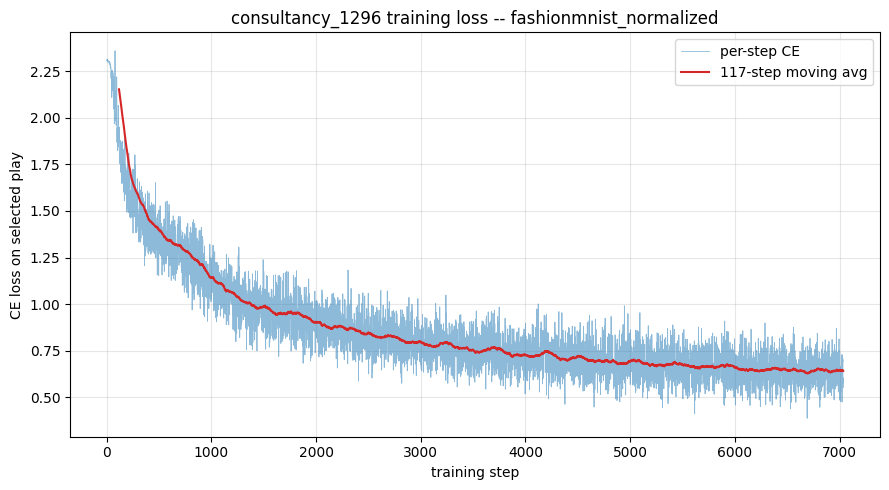

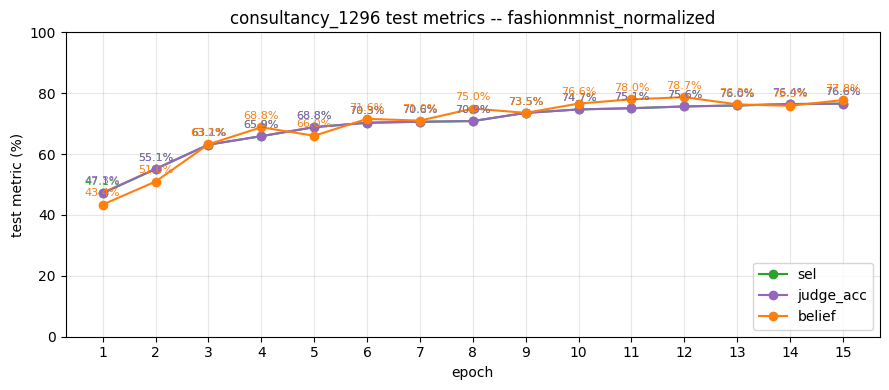

  weights at /kaggle/working/bitarg_weights/judge_consultancy_1296_fashionmnist_normalized.pt

##############################################################################
# consultancy_324  (2/7)  bits=0  branching=(324,)  cell_paths=324  evals=324
# judge: 56170 params, head_in=74, n_arg_dims=0
##############################################################################


consultancy_324 epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_324] epoch 01/15 | avg train loss 1.7218 | sel=47.99% | judge_acc=48.00% | belief=45.76% | elapsed 0.6 min


consultancy_324 epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_324] epoch 02/15 | avg train loss 1.2567 | sel=57.70% | judge_acc=57.70% | belief=57.79% | elapsed 1.1 min


...

  [consultancy_324] epoch 13/15 | avg train loss 0.7372 | sel=73.67% | judge_acc=73.69% | belief=73.60% | elapsed 7.3 min


consultancy_324 epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_324] epoch 14/15 | avg train loss 0.7322 | sel=73.40% | judge_acc=73.41% | belief=74.01% | elapsed 7.8 min


consultancy_324 epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_324] epoch 15/15 | avg train loss 0.7243 | sel=73.57% | judge_acc=73.54% | belief=74.65% | elapsed 8.4 min


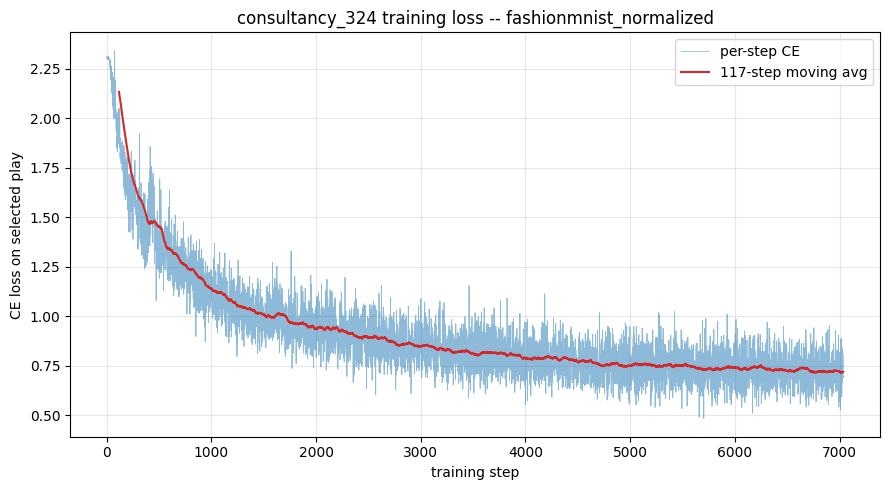

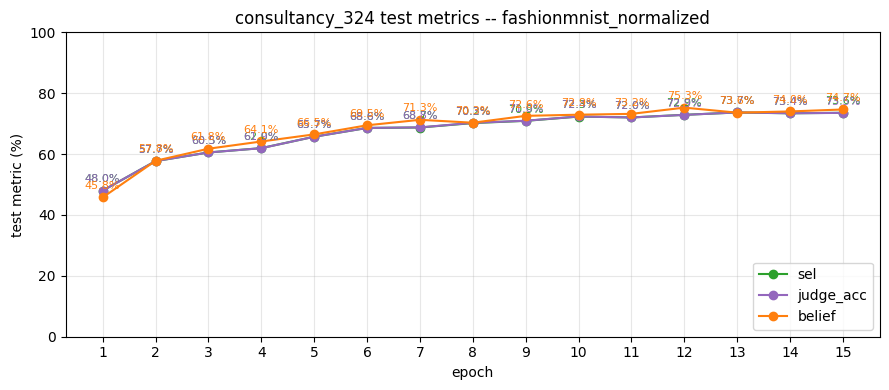

  weights at /kaggle/working/bitarg_weights/judge_consultancy_324_fashionmnist_normalized.pt

##############################################################################
# consultancy_bits_324  (3/7)  bits=4  branching=(324,)  cell_paths=324  evals=5184
# judge: 56426 params, head_in=78, n_arg_dims=4
##############################################################################


consultancy_bits_324 epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_bits_324] epoch 01/15 | avg train loss 1.7505 | sel=42.50% | judge_acc=42.65% | belief=37.39% | elapsed 1.5 min


consultancy_bits_324 epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_bits_324] epoch 02/15 | avg train loss 1.2749 | sel=54.09% | judge_acc=54.15% | belief=53.24% | elapsed 3.0 min


...

  [consultancy_bits_324] epoch 13/15 | avg train loss 0.7441 | sel=72.96% | judge_acc=72.94% | belief=74.11% | elapsed 19.3 min


consultancy_bits_324 epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_bits_324] epoch 14/15 | avg train loss 0.7388 | sel=73.28% | judge_acc=73.32% | belief=74.62% | elapsed 20.8 min


consultancy_bits_324 epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [consultancy_bits_324] epoch 15/15 | avg train loss 0.7295 | sel=72.48% | judge_acc=72.50% | belief=75.57% | elapsed 22.3 min


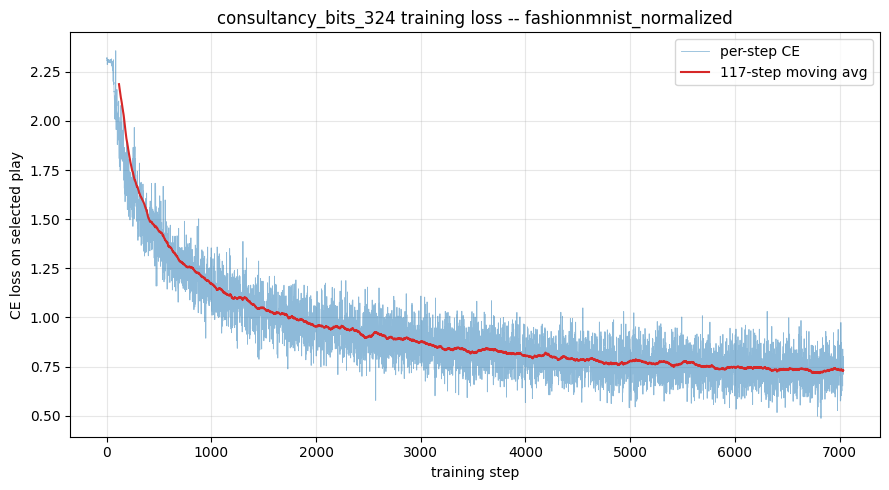

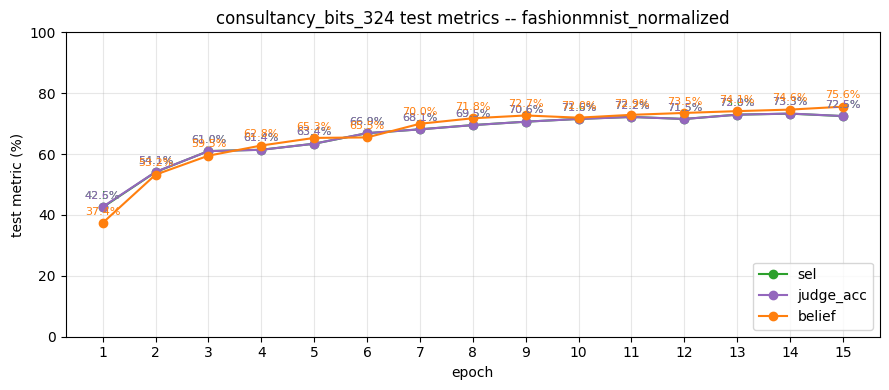

  weights at /kaggle/working/bitarg_weights/judge_consultancy_bits_324_fashionmnist_normalized.pt

##############################################################################
# 2turn_bits  (4/7)  bits=4  branching=(16, 16)  cell_paths=256  evals=4096
# judge: 57354 params, head_in=88, n_arg_dims=4
##############################################################################


2turn_bits epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [2turn_bits] epoch 01/15 | avg train loss 1.7503 | sel=42.75% | judge_acc=43.07% | belief=43.38% | elapsed 8.5 min


2turn_bits epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [2turn_bits] epoch 02/15 | avg train loss 1.3227 | sel=51.54% | judge_acc=51.44% | belief=53.57% | elapsed 16.9 min


...

  [2turn_bits] epoch 13/15 | avg train loss 0.7920 | sel=71.44% | judge_acc=71.35% | belief=72.10% | elapsed 110.0 min


2turn_bits epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [2turn_bits] epoch 14/15 | avg train loss 0.7790 | sel=71.68% | judge_acc=71.79% | belief=72.43% | elapsed 118.4 min


2turn_bits epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [2turn_bits] epoch 15/15 | avg train loss 0.7748 | sel=71.98% | judge_acc=71.93% | belief=72.40% | elapsed 126.9 min


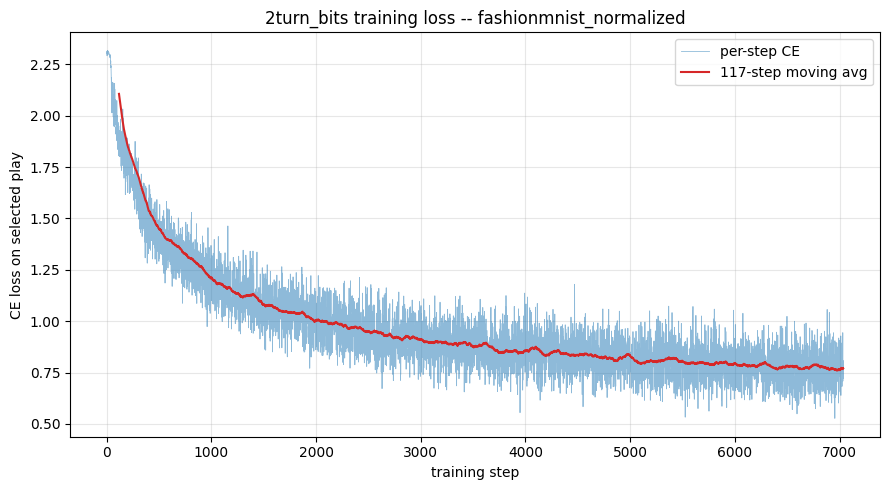

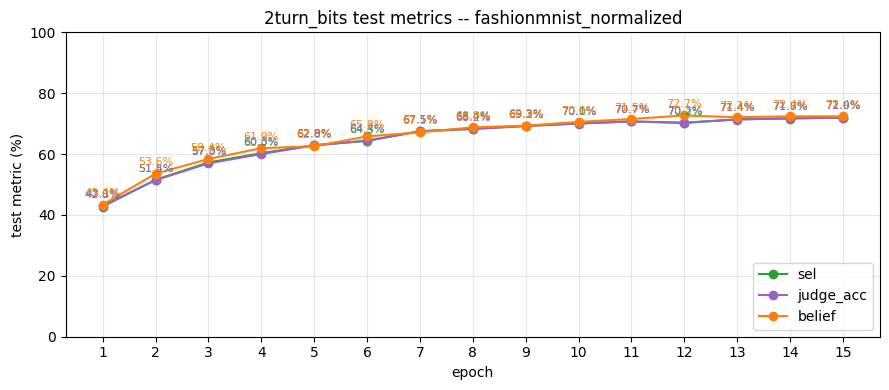

  weights at /kaggle/working/bitarg_weights/judge_2turn_bits_fashionmnist_normalized.pt

##############################################################################
# 2turn_control  (5/7)  bits=0  branching=(16, 16)  cell_paths=256  evals=256
# judge: 57098 params, head_in=84, n_arg_dims=0
##############################################################################


2turn_control epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [2turn_control] epoch 01/15 | avg train loss 1.7710 | sel=41.49% | judge_acc=41.52% | belief=42.07% | elapsed 0.9 min


2turn_control epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [2turn_control] epoch 02/15 | avg train loss 1.3097 | sel=52.50% | judge_acc=52.04% | belief=53.21% | elapsed 1.8 min


...

  [2turn_control] epoch 13/15 | avg train loss 0.7777 | sel=71.62% | judge_acc=71.65% | belief=71.89% | elapsed 11.8 min


2turn_control epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [2turn_control] epoch 14/15 | avg train loss 0.7601 | sel=71.49% | judge_acc=71.42% | belief=72.82% | elapsed 12.7 min


2turn_control epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [2turn_control] epoch 15/15 | avg train loss 0.7531 | sel=71.56% | judge_acc=71.65% | belief=73.11% | elapsed 13.7 min


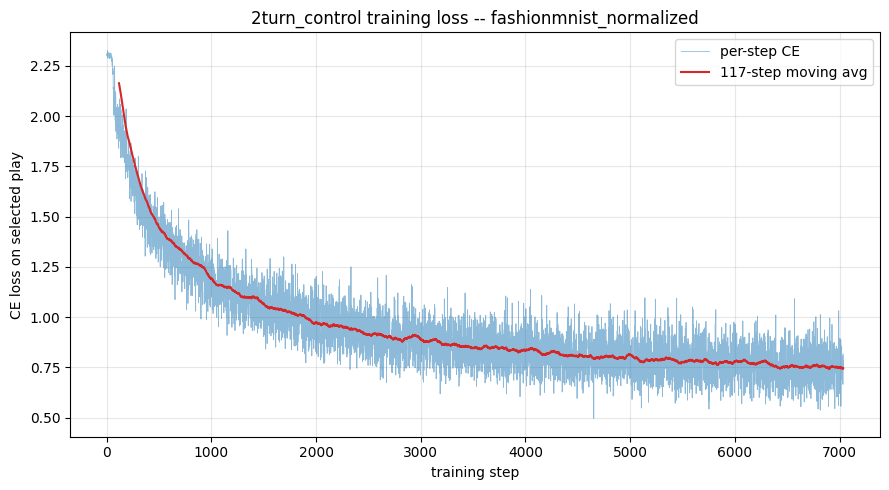

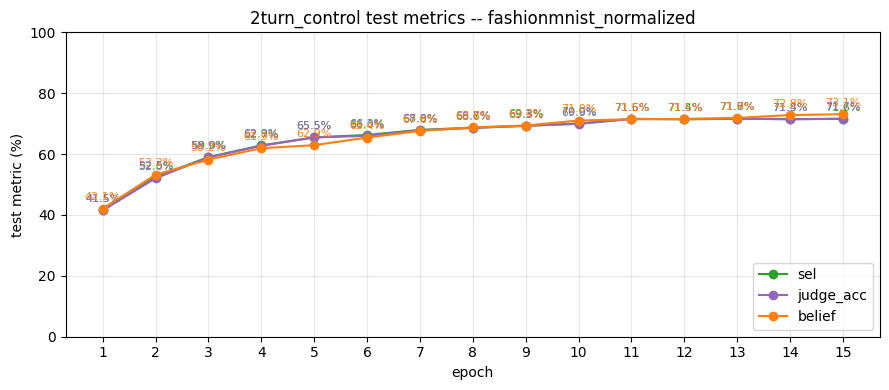

  weights at /kaggle/working/bitarg_weights/judge_2turn_control_fashionmnist_normalized.pt

##############################################################################
# 4turn_bits  (6/7)  bits=4  branching=(4, 4, 4, 4)  cell_paths=256  evals=4096
# judge: 57354 params, head_in=88, n_arg_dims=4
##############################################################################


4turn_bits epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [4turn_bits] epoch 01/15 | avg train loss 1.9062 | sel=39.68% | judge_acc=39.81% | belief=39.01% | elapsed 8.5 min


4turn_bits epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [4turn_bits] epoch 02/15 | avg train loss 1.4101 | sel=49.18% | judge_acc=49.39% | belief=47.11% | elapsed 16.9 min


...

  [4turn_bits] epoch 13/15 | avg train loss 0.9364 | sel=63.47% | judge_acc=63.53% | belief=63.15% | elapsed 109.9 min


4turn_bits epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [4turn_bits] epoch 14/15 | avg train loss 0.9317 | sel=63.83% | judge_acc=63.88% | belief=63.72% | elapsed 118.4 min


4turn_bits epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [4turn_bits] epoch 15/15 | avg train loss 0.9318 | sel=63.77% | judge_acc=63.56% | belief=64.04% | elapsed 126.8 min


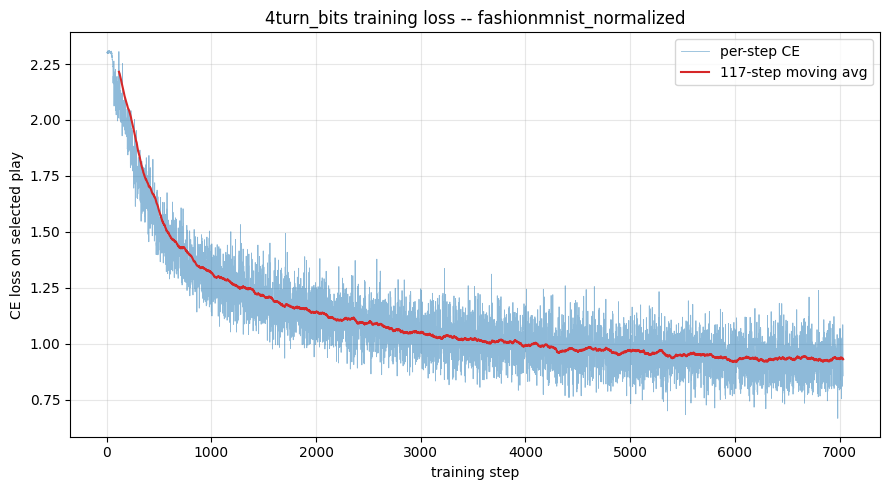

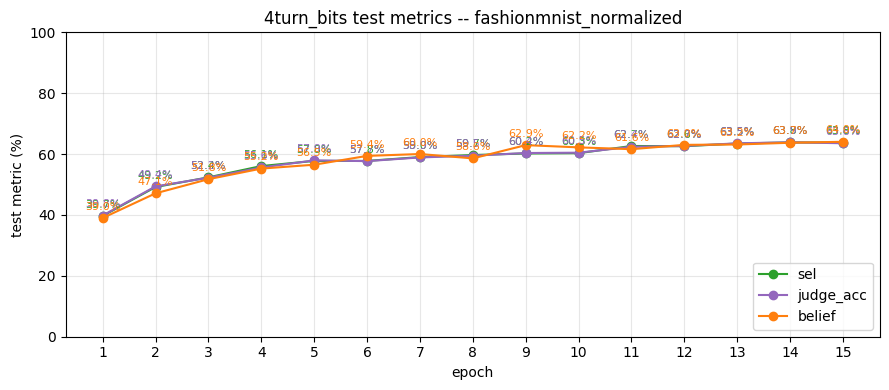

  weights at /kaggle/working/bitarg_weights/judge_4turn_bits_fashionmnist_normalized.pt

##############################################################################
# 4turn_control  (7/7)  bits=0  branching=(4, 4, 4, 4)  cell_paths=256  evals=256
# judge: 57098 params, head_in=84, n_arg_dims=0
##############################################################################


4turn_control epoch 1/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [4turn_control] epoch 01/15 | avg train loss 1.9423 | sel=37.26% | judge_acc=36.76% | belief=34.13% | elapsed 0.9 min


4turn_control epoch 2/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [4turn_control] epoch 02/15 | avg train loss 1.4440 | sel=48.82% | judge_acc=48.85% | belief=45.78% | elapsed 1.8 min


...

  [4turn_control] epoch 13/15 | avg train loss 0.9502 | sel=63.58% | judge_acc=63.58% | belief=64.62% | elapsed 11.8 min


4turn_control epoch 14/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [4turn_control] epoch 14/15 | avg train loss 0.9409 | sel=64.52% | judge_acc=64.56% | belief=64.08% | elapsed 12.7 min


4turn_control epoch 15/15:   0%|          | 0/469 [00:00<?, ?it/s]

  [4turn_control] epoch 15/15 | avg train loss 0.9373 | sel=63.84% | judge_acc=63.76% | belief=63.71% | elapsed 13.6 min


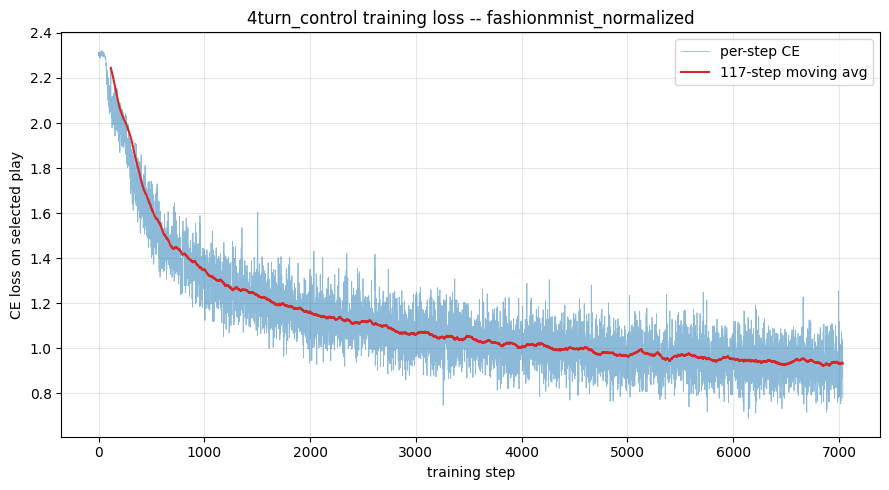

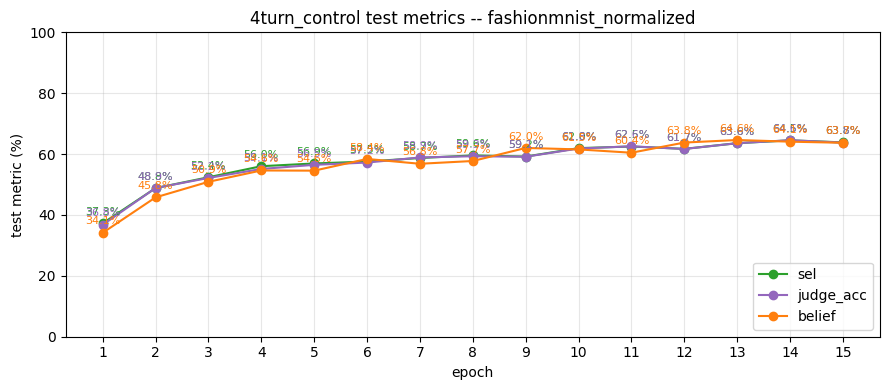

  weights at /kaggle/working/bitarg_weights/judge_4turn_control_fashionmnist_normalized.pt


In [19]:
for arm_idx, arm in enumerate(ARMS):
    torch.manual_seed(1000 * CONFIG['seed_base'] + arm_idx)
    judge = make_judge_for_arm(arm, DATA, CONFIG)
    # Re-seed AFTER construction (the two arms' judges consume different amounts
    # of init RNG) so that arms sharing a turn count see the same batch order
    # and the same mask candidate draws step for step -- a paired comparison,
    # which takes a little sampling noise out of the bits-minus-control delta.
    torch.manual_seed(CONFIG['seed_base'] * 97 + arm['n_turns'])
    n_par = sum(p.numel() for p in judge.parameters())
    print("\n" + "#" * 78)
    print(f"# {arm['name']}  ({arm_idx+1}/{len(ARMS)})  "
          f"bits={arm['n_bits']}  branching={arm['Ns']}  "
          f"cell_paths={arm['cell_paths']}  evals={arm['evals']}")
    print(f"# judge: {n_par} params, head_in={judge.head_in}, "
          f"n_arg_dims={arm['n_arg_dims']}")
    print("#" * 78)

    tag = f"{arm['name']}_{DATASET_TAG}"
    weights_path = os.path.join(CONFIG['weights_dir'], f'judge_{tag}.pt')
    step_losses, _, metrics = _train_one_judge(
        judge, DATA, CONFIG, arm, tag=arm['name'], weights_path=weights_path)

    np.save(os.path.join(CONFIG['data_dir'], f'step_loss_{tag}.npy'),
            np.asarray(step_losses, dtype=np.float32))
    for k in ('sel', 'judge_acc', 'belief'):
        np.save(os.path.join(CONFIG['data_dir'], f'epoch_{k}_{tag}.npy'),
                np.asarray([m[k] for m in metrics], dtype=np.float32))
    plot_loss_acc(step_losses, metrics, DATASET_TAG, arm['name'])

    ALL_RESULTS[arm['name']] = {'final': metrics[-1], 'history': metrics,
                                'arm': {k: arm[k] for k in
                                        ('n_turns', 'Vs', 'Ns', 'n_bits',
                                         'cell_paths', 'n_combos', 'evals',
                                         'arm_name', 'control')},
                                'weights': weights_path}
    print(f"  weights at {weights_path}")
    del judge; gc.collect()
    if CONFIG['device'].startswith('cuda'):
        torch.cuda.empty_cache()

## 3) Summary

In [20]:
print("=" * 104)
print(f"BIT-ARGUMENT DEBATE (last-d_B, claim-conditioned) -- {DATASET_TAG}")
print(f"channel {N_BITS} bits/play | head {CONFIG['mlp_hidden_layers']}x"
      f"{CONFIG['mlp_hidden']} | {CONFIG['epochs']} epochs")
print("=" * 104)
def _pct(x):
    return '      --' if (x is None or x != x) else f'{x*100:>7.2f}%'


hdr = (f"  {'run':<22s} {'masks':>7s} {'evals':>7s} {'sel acc':>8s} "
       f"{'judge acc':>9s} {'belief':>8s}")
print(hdr); print('  ' + '-' * (len(hdr) - 2))

r = ALL_RESULTS.get('gold')
if r is not None:
    print(f"  {'gold (full image)':<22s} {'--':>7s} {'--':>7s} {_pct(None):>8s} "
          f"{_pct(r['final']['judge_acc'])} {_pct(None):>8s}   <- ceiling")
r = ALL_RESULTS.get('random_mask')
if r is not None:
    m = r['final']
    print(f"  {'random mask (1)':<22s} {1:>7d} {'--':>7s} {_pct(None):>8s} "
          f"{_pct(m['judge_acc'])} {_pct(None):>8s}")
    for k, v in sorted(m.get('ensemble_by_budget', {}).items()):
        if k == 1:
            continue
        who = ', '.join(a['name'] for a in ARMS if a['cell_paths'] == k)
        print(f"  {'random mask (ens.)':<22s} {k:>7d} {'--':>7s} {_pct(None):>8s} "
              f"{_pct(v)} {_pct(None):>8s}   <- budget of {who}")
    if m.get('ensemble_acc_full') == m.get('ensemble_acc_full'):     # not nan
        print(f"  {'random mask (ens. ALL)':<22s} "
              f"{58905:>7d} {'--':>7s} {_pct(None):>8s} "
              f"{_pct(m['ensemble_acc_full'])} {_pct(None):>8s}"
              f"   <- zero-capability floor")
for arm in ARMS:
    r = ALL_RESULTS.get(arm['name'])
    if r is None:
        continue
    m = r['final']
    print(f"  {arm['name']:<22s} {arm['cell_paths']:>7d} {arm['evals']:>7d} "
          f"{_pct(m['sel'])} {_pct(m['judge_acc'])} {_pct(m['belief'])}")

print()
for arm in ARMS:
    if arm['control'] is None or arm['name'] not in ALL_RESULTS:
        continue
    if arm['control'] not in ALL_RESULTS:
        continue
    g = ALL_RESULTS[arm['name']]['final']
    c = ALL_RESULTS[arm['control']]['final']
    print(f"{arm['name']} minus {arm['control']} (pp): "
          f"sel {100*(g['sel']-c['sel']):+6.2f}   "
          f"judge {100*(g['judge_acc']-c['judge_acc']):+6.2f}")
    for k, nm in ((arm['name'], 'bits'), (arm['control'], 'ctrl')):
        h = [m['judge_acc'] for m in ALL_RESULTS[k]['history']][-3:]
        print(f"    {nm:<5s} judge_acc last 3 epochs: "
              f"{', '.join(f'{x*100:.2f}' for x in h)}")

print()
ref = {}
_rm = ALL_RESULTS.get('random_mask', {}).get('final', {})
_by_budget = _rm.get('ensemble_by_budget', {})
if _rm.get('ensemble_acc_full') == _rm.get('ensemble_acc_full'):
    ref['ensemble(all masks)'] = _rm['ensemble_acc_full']
if 'gold' in ALL_RESULTS:
    ref['gold'] = ALL_RESULTS['gold']['final']['judge_acc']
for a in ARMS:
    if a['arm_name'] == 'consultancy' and a['name'] in ALL_RESULTS:
        ref[a['name']] = ALL_RESULTS[a['name']]['final']['judge_acc']
for a in ARMS:
    if a['name'] not in ALL_RESULTS:
        continue
    acc = ALL_RESULTS[a['name']]['final']['judge_acc']
    r2 = {k: v for k, v in ref.items() if k != a['name']}
    if a['cell_paths'] in _by_budget:      # the sharp one: same mask budget
        r2[f"ensemble@{a['cell_paths']} masks"] = _by_budget[a['cell_paths']]
    print(f"{a['name']:<22s} judge acc minus " +
          '   '.join(f"{k} {100*(acc-v):+.2f}" for k, v in r2.items()))

BIT-ARGUMENT DEBATE (last-d_B, claim-conditioned) -- fashionmnist_normalized
channel 4 bits/play | head 3x64 | 15 epochs
  run                      masks   evals  sel acc judge acc   belief
  ------------------------------------------------------------------
  gold (full image)           --      --       --   95.36%       --   <- ceiling
  random mask (1)              1      --       --   51.35%       --
  random mask (ens.)         256      --       --   64.36%       --   <- budget of 2turn_bits, 2turn_control, 4turn_bits, 4turn_control
  random mask (ens.)         324      --       --   64.46%       --   <- budget of consultancy_324, consultancy_bits_324
  random mask (ens.)        1296      --       --   64.60%       --   <- budget of consultancy_1296
  random mask (ens. ALL)   58905      --       --   64.57%       --   <- zero-capability floor
  consultancy_1296          1296    1296   76.58%   76.58%   77.76%
  consultancy_324            324     324   73.57%   73.54%   74.65%
  co

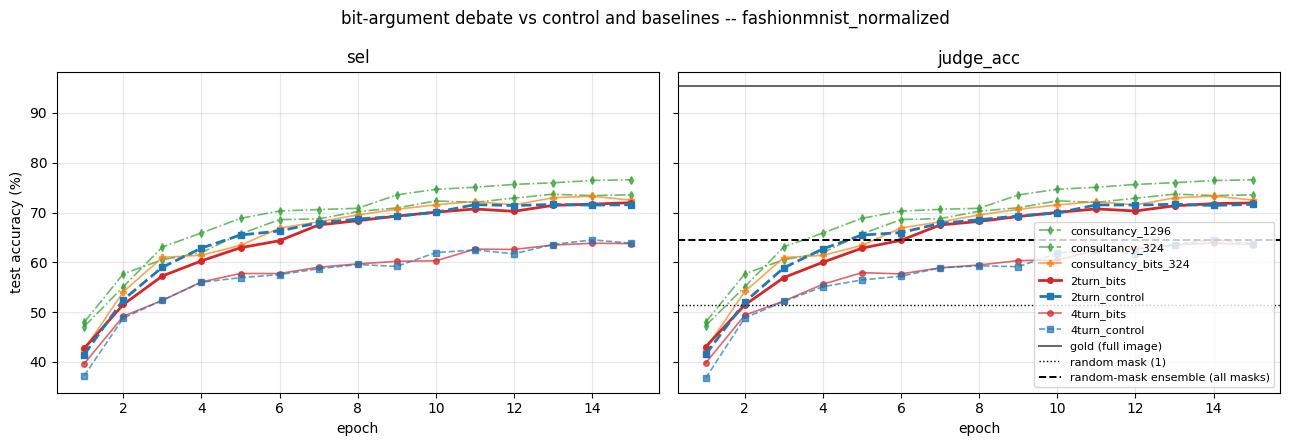

saved /kaggle/working/bitarg_plots/comparison_fashionmnist_normalized.png


In [21]:
# Comparison plot: test metrics per epoch, all arms.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
styles = {'bits': ('C3', '-', 'o'), 'control': ('C0', '--', 's'),
          'consultancy_bits': ('C1', '-', 'P'),
          'consultancy': ('C2', '-.', 'd')}
_extra = ['C2', 'C4', 'C5', 'C6', 'C8', 'C9']
for _i, _a in enumerate(a for a in ARMS if a['arm_name'] not in styles):
    styles.setdefault(_a['name'], (_extra[_i % len(_extra)], '-.', 'd'))
for ax, metric in zip(axes, ('sel', 'judge_acc')):
    for arm in ARMS:
        r = ALL_RESULTS.get(arm['name'])
        if r is None:
            continue
        c, ls, mk = styles.get(arm['name'],
                               styles.get(arm['arm_name'], ('C7', ':', '^')))
        lw = 2.0 if arm['n_turns'] == 2 else 1.2
        alpha = 1.0 if arm['n_turns'] == 2 else 0.7
        ys = [m[metric] * 100 for m in r['history']]
        ax.plot(np.arange(1, len(ys) + 1), ys, color=c, ls=ls, marker=mk,
                lw=lw, alpha=alpha, ms=4, label=arm['name'])
    gd = ALL_RESULTS.get('gold')
    if gd is not None and metric == 'judge_acc':
        ax.axhline(gd['final']['judge_acc'] * 100, color='0.4', lw=1.4, ls='-',
                   label='gold (full image)')
    rb = ALL_RESULTS.get('random_mask')
    if rb is not None and metric == 'judge_acc':
        ax.axhline(rb['final']['judge_acc'] * 100, color='k', lw=1, ls=':',
                   label='random mask (1)')
        _e = rb['final'].get('ensemble_acc_full')
        if _e != _e:
            _bb = rb['final'].get('ensemble_by_budget', {})
            _e = _bb[max(_bb)] if _bb else float('nan')
        ax.axhline(_e * 100, color='k', lw=1.4, ls='--',
                   label='random-mask ensemble (all masks)')
    ax.set_xlabel('epoch'); ax.set_title(metric); ax.grid(True, alpha=0.3)
axes[0].set_ylabel('test accuracy (%)')
axes[1].legend(fontsize=8, loc='lower right')
fig.suptitle(f'bit-argument debate vs control and baselines -- {DATASET_TAG}')
fig.tight_layout()
p = os.path.join(CONFIG['plot_dir'], f'comparison_{DATASET_TAG}.png')
fig.savefig(p, dpi=150, bbox_inches='tight'); plt.show(); plt.close(fig)
print(f"saved {p}")

## 4) What did the bits end up meaning?

Two questions, both on the test set with the final judges:

1. **Is the channel used at all?** Re-score the *same* selected plays with the
   bits replaced by a random codeword. If judge accuracy / belief barely moves,
   the equilibrium ignored the channel and the arm is just its control with a
   wasted search dimension.
2. **What does it encode?** Per bit, in reveal order and labelled by emitter:
   $P(b{=}1)$, $I(b;y)$, $I(b;\text{claim})$, and $I(b;y \mid \text{claim})$ —
   what the bit says about the truth *beyond* the claim it accompanies. Plus
   $P(\text{claim}{=}y \mid b)$, which separates if the channel is being used
   to flag honesty, and the entropy of the realised 4-bit codeword, which says
   how much of the channel is used at all.

In [22]:
def _mutual_info(a, b, na, nb):
    """MI in bits between two integer tensors."""
    joint = torch.zeros(na, nb)
    idx = (a.cpu() * nb + b.cpu())
    joint.view(-1).scatter_add_(0, idx, torch.ones_like(idx, dtype=torch.float))
    joint /= joint.sum()
    pa = joint.sum(1, keepdim=True)
    pb = joint.sum(0, keepdim=True)
    denom = pa * pb
    m = joint > 0
    return float((joint[m] * torch.log2(joint[m] / denom.expand_as(joint)[m])).sum())


def _cond_mutual_info(a, b, c, na, nb, nc):
    """I(a; b | c) in bits, averaged over c."""
    total = 0.0
    n = a.numel()
    for v in range(nc):
        m = (c == v)
        cnt = int(m.sum())
        if cnt < 2:
            continue
        total += (cnt / n) * _mutual_info(a[m], b[m], na, nb)
    return total


@torch.no_grad()
def analyze_symbols(judge, data, config, arm, n_shuffles=1):
    """Per-BIT diagnostics on the test set, plus the randomized-channel
    ablation. Bits are reported in reveal order with their emitter."""
    judge.eval()
    Xte, yte = data['X_test'], data['y_test']
    n, B = Xte.size(0), config['eval_batch']
    nb = arm['n_bits']
    bits, claims, ys = [], [], []
    acc_real = acc_rand = 0
    belief_real = belief_rand = 0.0
    for start in range(0, n, B):
        end = min(start + B, n)
        xb, yb = Xte[start:end], yte[start:end]
        sel_input, claim, dB_star, args = arm['find_best'](judge, xb, config, data, arm)
        logits = judge(sel_input, claim, dB_star, args)
        p = torch.softmax(logits, dim=-1)
        ar = torch.arange(xb.size(0), device=xb.device)
        acc_real += (logits.argmax(-1) == yb).sum().item()
        belief_real += p[ar, claim].sum().item()
        bits.append(args.long().cpu()); claims.append(claim.cpu()); ys.append(yb.cpu())
        # ablation: identical play, random bits
        for _ in range(n_shuffles):
            rand_args = arm['arg_feats'][
                torch.randint(0, arm['n_combos'], (xb.size(0),), device=xb.device)]
            lg = judge(sel_input, claim, dB_star, rand_args)
            acc_rand += (lg.argmax(-1) == yb).sum().item()
            belief_rand += torch.softmax(lg, -1)[ar, claim].sum().item()
    bits = torch.cat(bits); claims = torch.cat(claims); ys = torch.cat(ys)
    owners = bit_owners(arm['n_turns'], arm['bits_per_decision'])
    return {
        'acc_real':      acc_real / n,
        'acc_random':    acc_rand / (n * n_shuffles),
        'belief_real':   belief_real / n,
        'belief_random': belief_rand / (n * n_shuffles),
        'owners':        owners,
        'p_one':         [float(bits[:, i].float().mean()) for i in range(nb)],
        'MI_bit_y':      [_mutual_info(bits[:, i], ys, 2, NUM_CLASSES)
                          for i in range(nb)],
        'MI_bit_claim':  [_mutual_info(bits[:, i], claims, 2, NUM_CLASSES)
                          for i in range(nb)],
        'MI_bit_y_given_claim': [
            _cond_mutual_info(bits[:, i], ys, claims, 2, NUM_CLASSES, NUM_CLASSES)
            for i in range(nb)],
        # P(A's claim is right | this bit) -- if the channel is used to flag
        # honesty, these two numbers separate.
        'correct_given_bit': [
            [float((ys[bits[:, i] == v] == claims[bits[:, i] == v]).float().mean())
             if (bits[:, i] == v).any() else float('nan') for v in (0, 1)]
            for i in range(nb)],
        # how much of the 4-bit codeword space is actually used
        'codeword_entropy': max(0.0, float(-(lambda q: (q[q > 0] * torch.log2(q[q > 0])).sum())(
            torch.bincount(
                (bits * (2 ** torch.arange(nb - 1, -1, -1))).sum(1),
                minlength=arm['n_combos']).float() / bits.size(0)))),
    }

In [23]:
for arm in ARMS:
    if arm['n_bits'] == 0 or arm['name'] not in ALL_RESULTS:
        continue
    ck = torch.load(ALL_RESULTS[arm['name']]['weights'], map_location=CONFIG['device'])
    judge = make_judge_for_arm(arm, DATA, CONFIG)
    judge.load_state_dict(ck['state_dict'])
    a = analyze_symbols(judge, DATA, CONFIG, arm)
    ALL_RESULTS[arm['name']]['symbol_analysis'] = a
    print("=" * 78)
    print(f"{arm['name']}  ({arm['n_bits']} bits/play, "
          f"{arm['bits_per_decision']} per decision, alphabets {arm['Vs']})")
    print("=" * 78)
    print(f"  judge acc  real bits {a['acc_real']*100:6.2f}%   "
          f"random bits {a['acc_random']*100:6.2f}%   "
          f"drop {100*(a['acc_real']-a['acc_random']):+.2f} pp")
    print(f"  belief     real bits {a['belief_real']*100:6.2f}%   "
          f"random bits {a['belief_random']*100:6.2f}%")
    print(f"  codeword entropy {a['codeword_entropy']:.3f} of "
          f"{arm['n_bits']} bits available")
    for i in range(arm['n_bits']):
        print(f"  bit {i+1} ({a['owners'][i]}): P(1)={a['p_one'][i]:.3f}  "
              f"I(b;y)={a['MI_bit_y'][i]:.4f} bits  "
              f"I(b;claim)={a['MI_bit_claim'][i]:.4f}  "
              f"I(b;y|claim)={a['MI_bit_y_given_claim'][i]:.4f}  "
              f"P(claim==y | b)={['%.3f' % x for x in a['correct_given_bit'][i]]}")
    del judge; gc.collect()
    if CONFIG['device'].startswith('cuda'):
        torch.cuda.empty_cache()

consultancy_bits_324  (4 bits/play, 4 per decision, alphabets (16,))
  judge acc  real bits  73.57%   random bits  73.46%   drop +0.11 pp
  belief     real bits  75.52%   random bits  71.06%
  codeword entropy 1.306 of 4 bits available
  bit 1 (A): P(1)=0.942  I(b;y)=0.0155 bits  I(b;claim)=0.0705  I(b;y|claim)=0.0095  P(claim==y | b)=['0.562', '0.746']
  bit 2 (A): P(1)=0.913  I(b;y)=0.0750 bits  I(b;claim)=0.1266  I(b;y|claim)=0.0063  P(claim==y | b)=['0.528', '0.756']
  bit 3 (A): P(1)=0.963  I(b;y)=0.0107 bits  I(b;claim)=0.0577  I(b;y|claim)=0.0083  P(claim==y | b)=['0.527', '0.744']
  bit 4 (A): P(1)=0.877  I(b;y)=0.0851 bits  I(b;claim)=0.1924  I(b;y|claim)=0.0123  P(claim==y | b)=['0.540', '0.763']
2turn_bits  (4 bits/play, 2 per decision, alphabets (4, 4))
  judge acc  real bits  71.47%   random bits  67.97%   drop +3.50 pp
  belief     real bits  72.33%   random bits  63.66%
  codeword entropy 3.271 of 4 bits available
  bit 1 (A): P(1)=0.638  I(b;y)=0.4638 bits  I(b;claim)=0

In [24]:
import json
summary = {k: {'final': v['final'], 'arm': v['arm'],
               'symbol_analysis': v.get('symbol_analysis')}
           for k, v in ALL_RESULTS.items()}
p = os.path.join(CONFIG['data_dir'], f'summary_{DATASET_TAG}.json')
with open(p, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"saved {p}")

saved /kaggle/working/bitarg_data/summary_fashionmnist_normalized.json
